# Predictive Maintenance of Turbofan Engines using NASA CMAPSS Dataset

**Course:** Data Analytics  
**Dataset:** NASA CMAPSS FD001 — Commercial Modular Aero-Propulsion System Simulation  
**Objective:** Analyse turbofan engine sensor data to predict Remaining Useful Life (RUL)
and identify distinct engine degradation profiles using machine learning.

---

## 1. Setup & Libraries

We import standard data science libraries: `pandas` and `numpy` for data manipulation,
`matplotlib` and `seaborn` for visualisation, and `sklearn` for machine learning.
All analysis is performed on the FD001 sub-dataset — the simplest configuration
with one operating condition and one fault mode, making it ideal for a focused study.

In [1]:
# Data handling
import pandas as pd        # for tables (like Excel, but in Python)
import numpy as np         # for maths on numbers

# Visualization
import matplotlib.pyplot as plt   # for drawing graphs
import seaborn as sns             # makes graphs look nicer

# We'll import ML libraries later when we need them
# This keeps things clean and organized

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()
# Uploading:
# train_FD001.txt, test_FD001.txt, RUL_FD001.txt

Saving RUL_FD001.txt to RUL_FD001.txt
Saving test_FD001.txt to test_FD001.txt
Saving train_FD001.txt to train_FD001.txt


In [3]:
# We create a list of 26 names — exactly matching the 26 columns in the file

column_names = [
    'engine_id',      # which engine (1 to 100)
    'cycle',          # which flight cycle (time step)
    'op_setting_1',   # operational setting 1 (altitude)
    'op_setting_2',   # operational setting 2 (Mach number)
    'op_setting_3',   # operational setting 3 (throttle)
    'sensor_1',  'sensor_2',  'sensor_3',  'sensor_4',  'sensor_5',
    'sensor_6',  'sensor_7',  'sensor_8',  'sensor_9',  'sensor_10',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
    'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20',
    'sensor_21'
]

print(f"Total columns defined: {len(column_names)}")  # print 26

Total columns defined: 26


## 2. Data Loading & Cleaning

The CMAPSS dataset consists of three files for FD001:
- **train_FD001.txt** — complete run-to-failure records for 100 engines
- **test_FD001.txt** — truncated records (cut off before failure) for 100 engines  
- **RUL_FD001.txt** — true Remaining Useful Life at the test cut-off point

Each file contains 26 space-separated columns with no header row.
Columns represent: engine ID, cycle number, 3 operational settings, and 21 sensor readings.

In [4]:
# Load training data
train_df = pd.read_csv('train_FD001.txt',
                        sep=r'\s+',         # r'' = raw string, fixes the warning
                        header=None,
                        names=column_names)

# Load test data
test_df = pd.read_csv('test_FD001.txt',
                       sep=r'\s+',
                       header=None,
                       names=column_names)

# Load true RUL values
rul_df = pd.read_csv('RUL_FD001.txt',
                      sep=r'\s+',
                      header=None,
                      names=['true_rul'])

print("Training data shape:", train_df.shape)
print("Test data shape    :", test_df.shape)
print("RUL data shape     :", rul_df.shape)

Training data shape: (20631, 26)
Test data shape    : (13096, 26)
RUL data shape     : (100, 1)


In [5]:
print("=== First 5 rows of training data ===")
print(train_df.head())

print("\n=== Basic info (column types, non-null counts) ===")
print(train_df.info())

print("\n=== Basic statistics (mean, min, max of each column) ===")
print(train_df.describe().round(2))

=== First 5 rows of training data ===
   engine_id  cycle  op_setting_1  op_setting_2  op_setting_3  sensor_1  \
0          1      1       -0.0007       -0.0004         100.0    518.67   
1          1      2        0.0019       -0.0003         100.0    518.67   
2          1      3       -0.0043        0.0003         100.0    518.67   
3          1      4        0.0007        0.0000         100.0    518.67   
4          1      5       -0.0019       -0.0002         100.0    518.67   

   sensor_2  sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  \
0    641.82   1589.70   1400.60     14.62  ...     521.66    2388.02   
1    642.15   1591.82   1403.14     14.62  ...     522.28    2388.07   
2    642.35   1587.99   1404.20     14.62  ...     522.42    2388.03   
3    642.35   1582.79   1401.87     14.62  ...     522.86    2388.08   
4    642.37   1582.85   1406.22     14.62  ...     522.19    2388.04   

   sensor_14  sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  \
0    81

In [6]:
print("=== Missing values per column ===")
missing = train_df.isnull().sum()
print(missing)

print(f"\nTotal missing values: {missing.sum()}")
# Should print 0 — CMAPSS is clean

=== Missing values per column ===
engine_id       0
cycle           0
op_setting_1    0
op_setting_2    0
op_setting_3    0
sensor_1        0
sensor_2        0
sensor_3        0
sensor_4        0
sensor_5        0
sensor_6        0
sensor_7        0
sensor_8        0
sensor_9        0
sensor_10       0
sensor_11       0
sensor_12       0
sensor_13       0
sensor_14       0
sensor_15       0
sensor_16       0
sensor_17       0
sensor_18       0
sensor_19       0
sensor_20       0
sensor_21       0
dtype: int64

Total missing values: 0


In [7]:
# Calculate standard deviation of each sensor column
# Standard deviation = how much values vary. If std = 0, the sensor never changes.

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]  # list of all 21 sensor names

std_devs = train_df[sensor_cols].std()

print("=== Standard deviation of each sensor ===")
print(std_devs.round(4))

# Find sensors with zero (or near-zero) standard deviation
constant_sensors = std_devs[std_devs < 0.001].index.tolist()
print(f"\nConstant sensors to drop: {constant_sensors}")

=== Standard deviation of each sensor ===
sensor_1      0.0000
sensor_2      0.5001
sensor_3      6.1311
sensor_4      9.0006
sensor_5      0.0000
sensor_6      0.0014
sensor_7      0.8851
sensor_8      0.0710
sensor_9     22.0829
sensor_10     0.0000
sensor_11     0.2671
sensor_12     0.7376
sensor_13     0.0719
sensor_14    19.0762
sensor_15     0.0375
sensor_16     0.0000
sensor_17     1.5488
sensor_18     0.0000
sensor_19     0.0000
sensor_20     0.1807
sensor_21     0.1083
dtype: float64

Constant sensors to drop: ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


In [8]:
# Drop them from both train and test
train_df = train_df.drop(columns=constant_sensors)
test_df  = test_df.drop(columns=constant_sensors)

# Update our sensor list to only the useful ones
useful_sensors = [s for s in sensor_cols if s not in constant_sensors]

print(f"Sensors remaining: {len(useful_sensors)}")
print(f"Useful sensors: {useful_sensors}")

Sensors remaining: 15
Useful sensors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [9]:
print("=== Training dataframe after cleaning ===")
print(f"Shape: {train_df.shape}")
print(f"Columns: {list(train_df.columns)}")
print("\nFirst 3 rows:")
print(train_df.head(3))

=== Training dataframe after cleaning ===
Shape: (20631, 20)
Columns: ['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

First 3 rows:
   engine_id  cycle  op_setting_1  op_setting_2  op_setting_3  sensor_2  \
0          1      1       -0.0007       -0.0004         100.0    641.82   
1          1      2        0.0019       -0.0003         100.0    642.15   
2          1      3       -0.0043        0.0003         100.0    642.35   

   sensor_3  sensor_4  sensor_6  sensor_7  sensor_8  sensor_9  sensor_11  \
0   1589.70   1400.60     21.61    554.36   2388.06   9046.19      47.47   
1   1591.82   1403.14     21.61    553.75   2388.04   9044.07      47.49   
2   1587.99   1404.20     21.61    554.26   2388.08   9052.94      47.27   

   sensor_12  sensor_13  sensor_14  sensor_15  sen

## 3. Exploratory Data Analysis (EDA)

EDA is performed to understand the structure and behaviour of the sensor data
before any modelling. We examine:
- Engine lifetime distributions across the fleet
- Sensor degradation trends over time (the core signal for RUL prediction)
- Inter-sensor correlations to identify redundant features
- Outlier detection using boxplots and z-score analysis

In [10]:
# Set a clean visual style for all plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)   # default plot size
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Plot style set!")

Plot style set!


How long do engines last?
Concept: Each engine starts at cycle 1 and runs until it fails. The total number of cycles it survives is its lifetime. We want to see — do all engines last roughly the same time, or is there huge variation? This matters because it tells us how hard the RUL prediction problem is.

=== Engine lifetime statistics ===
Shortest engine life : 128 cycles
Longest engine life  : 362 cycles
Average engine life  : 206.3 cycles
Std deviation        : 46.3 cycles


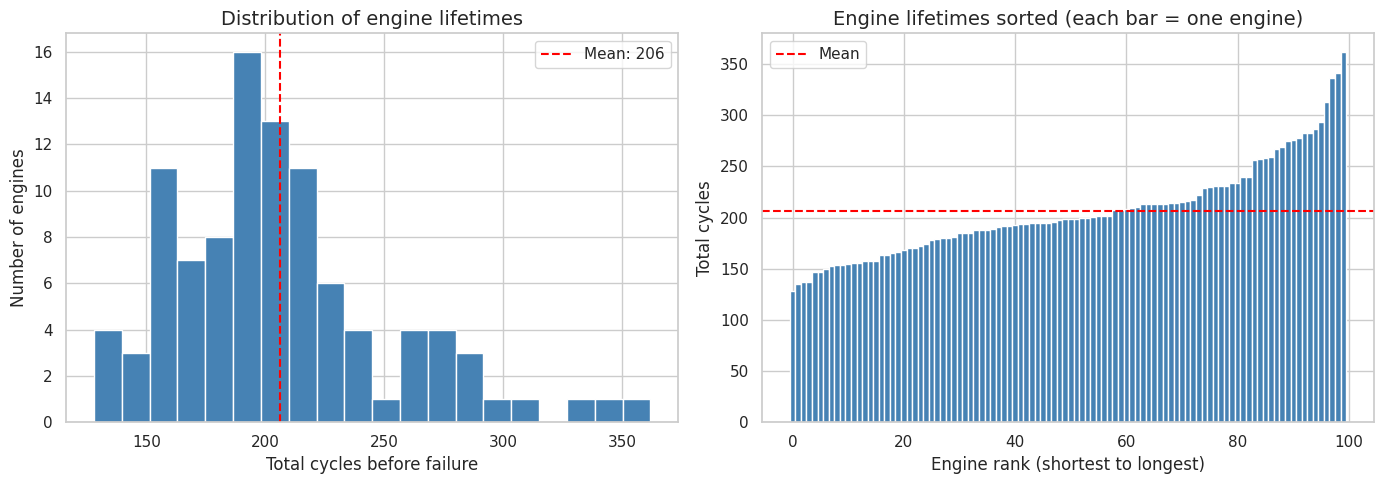

Plot saved!


In [11]:
# Find the maximum cycle for each engine — that's its total lifetime
engine_lifetimes = train_df.groupby('engine_id')['cycle'].max()

print("=== Engine lifetime statistics ===")
print(f"Shortest engine life : {engine_lifetimes.min()} cycles")
print(f"Longest engine life  : {engine_lifetimes.max()} cycles")
print(f"Average engine life  : {engine_lifetimes.mean():.1f} cycles")
print(f"Std deviation        : {engine_lifetimes.std():.1f} cycles")

# Plot the distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(engine_lifetimes, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of engine lifetimes')
axes[0].set_xlabel('Total cycles before failure')
axes[0].set_ylabel('Number of engines')
axes[0].axvline(engine_lifetimes.mean(), color='red', linestyle='--', label=f'Mean: {engine_lifetimes.mean():.0f}')
axes[0].legend()

# Sorted bar chart — each bar is one engine
axes[1].bar(range(len(engine_lifetimes)),
            sorted(engine_lifetimes.values),
            color='steelblue', width=1.0)
axes[1].set_title('Engine lifetimes sorted (each bar = one engine)')
axes[1].set_xlabel('Engine rank (shortest to longest)')
axes[1].set_ylabel('Total cycles')
axes[1].axhline(engine_lifetimes.mean(), color='red', linestyle='--', label='Mean')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot1_engine_lifetimes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

Sensor degradation trends over time
Concept: This is the most important plot in your EDA. A sensor that changes as an engine ages is useful for predicting failure. We pick a few engines and plot their sensor readings across all their cycles — you should literally see the engine wearing out.

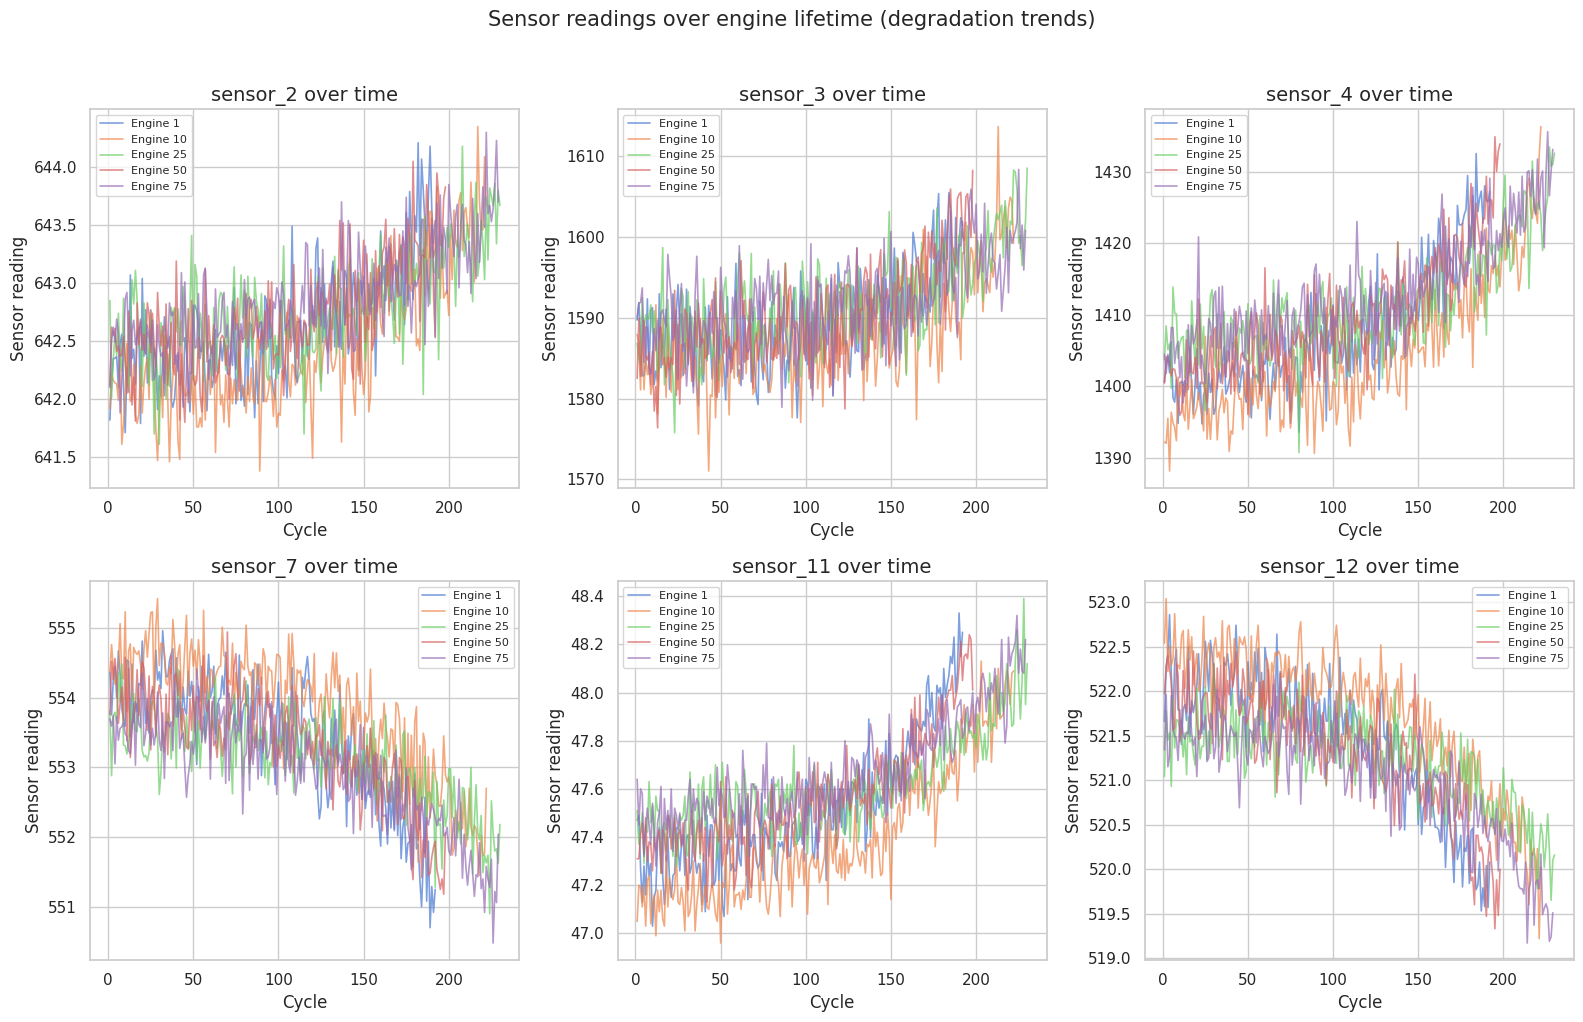

Plot saved!


In [12]:
# Pick 5 engines to visualize — spread across short, medium and long lifetimes
sample_engines = [1, 10, 25, 50, 75]

# Pick 6 sensors that typically show clear degradation trends
sensors_to_plot = ['sensor_2', 'sensor_3', 'sensor_4',
                   'sensor_7', 'sensor_11', 'sensor_12']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()  # makes it easier to loop through

for i, sensor in enumerate(sensors_to_plot):
    for engine_id in sample_engines:
        # Get data for just this one engine
        engine_data = train_df[train_df['engine_id'] == engine_id]
        axes[i].plot(engine_data['cycle'],
                     engine_data[sensor],
                     alpha=0.7,          # slight transparency so lines don't hide each other
                     linewidth=1.2,
                     label=f'Engine {engine_id}')

    axes[i].set_title(f'{sensor} over time')
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel('Sensor reading')
    axes[i].legend(fontsize=8)

plt.suptitle('Sensor readings over engine lifetime (degradation trends)',
             fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('plot2_sensor_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

The engines in sample_engines are chosen by ID number, not by lifetime rank. You are essentially picking engines blindly with no guarantee they represent the spread of the fleet.Engine 1 might happen to be medium-lived. A better approach is to select engines by lifetime percentile
Guaranteed to include short, medium, and long-lived



 Correlation heatmap
Concept: Correlation measures how closely two things move together. If sensor_2 goes up every time sensor_3 goes up, they are highly correlated. For our purposes, we want to know which sensors are correlated with each other (helps us understand redundancy) and which sensors might be correlated with the cycle (meaning they change as the engine ages — useful for prediction).
Correlation is always between -1 and +1:

+1 = move together perfectly
0 = no relationship
-1 = move in opposite directions perfectly

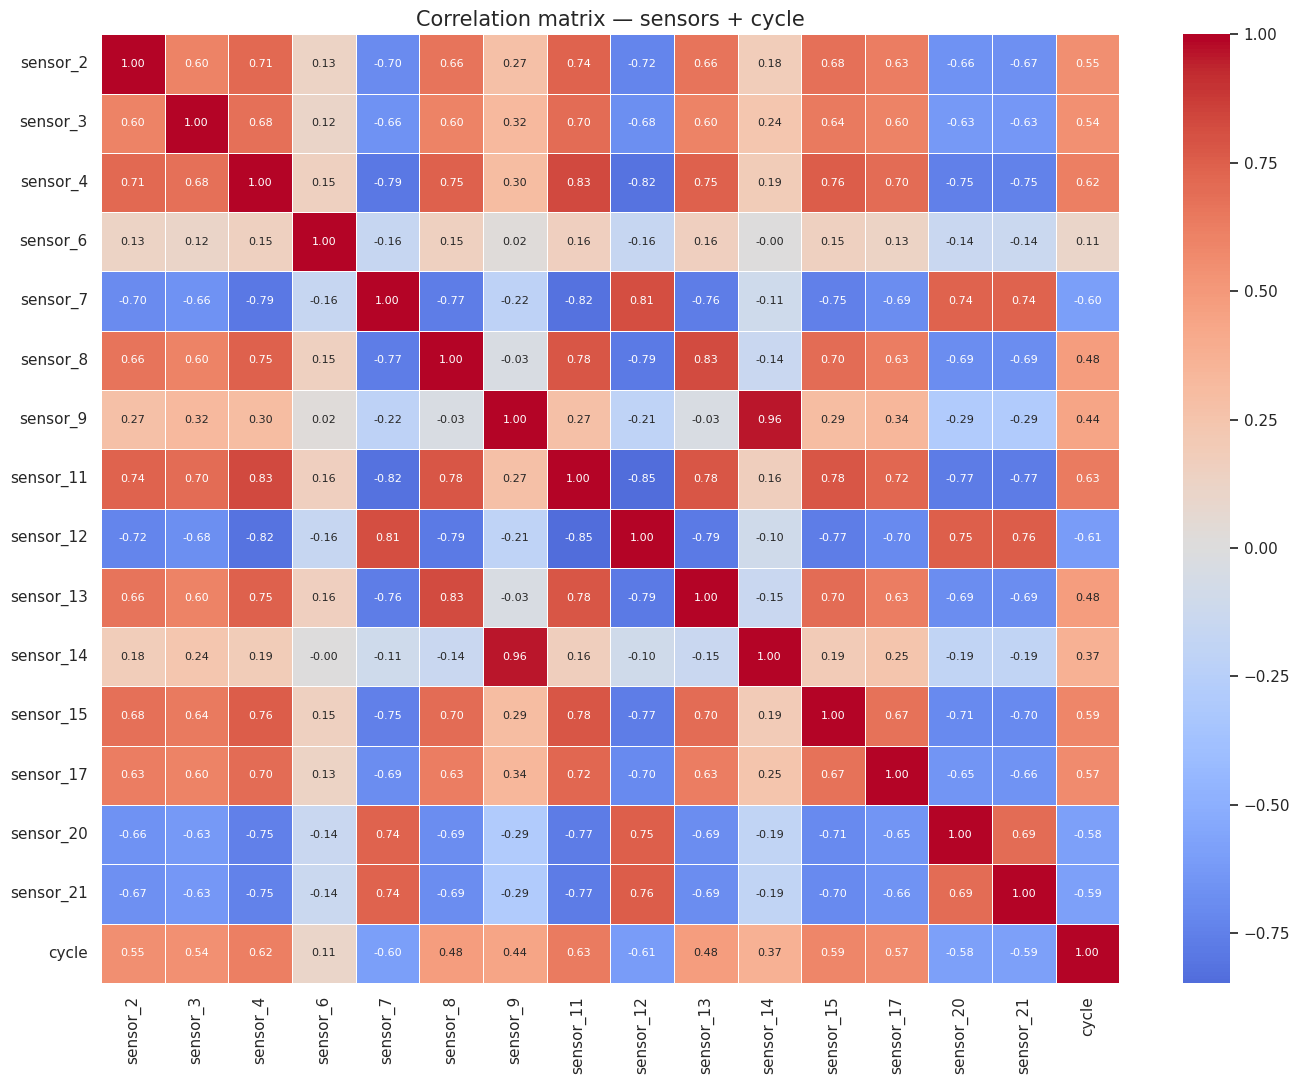

Plot saved!


In [13]:
# Select only the 15 sensor columns
sensor_cols_useful = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6',
                      'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11',
                      'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
                      'sensor_17', 'sensor_20', 'sensor_21']

# Calculate correlation matrix
corr_matrix = train_df[sensor_cols_useful + ['cycle']].corr()

# Plot heatmap
plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix,
            annot=True,          # show numbers inside each cell
            fmt='.2f',           # round to 2 decimal places
            cmap='coolwarm',     # blue = negative, red = positive correlation
            center=0,            # white = zero correlation
            linewidths=0.5,
            annot_kws={'size': 8})

plt.title('Correlation matrix — sensors + cycle', fontsize=15)
plt.tight_layout()
plt.savefig('plot3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

 Outlier detection with boxplots
Concept: A boxplot shows the spread of a sensor's values. The box covers the middle 50% of readings. Points outside the "whiskers" are outliers — unusually high or low readings. Outliers can be genuine anomalies or sensor errors.

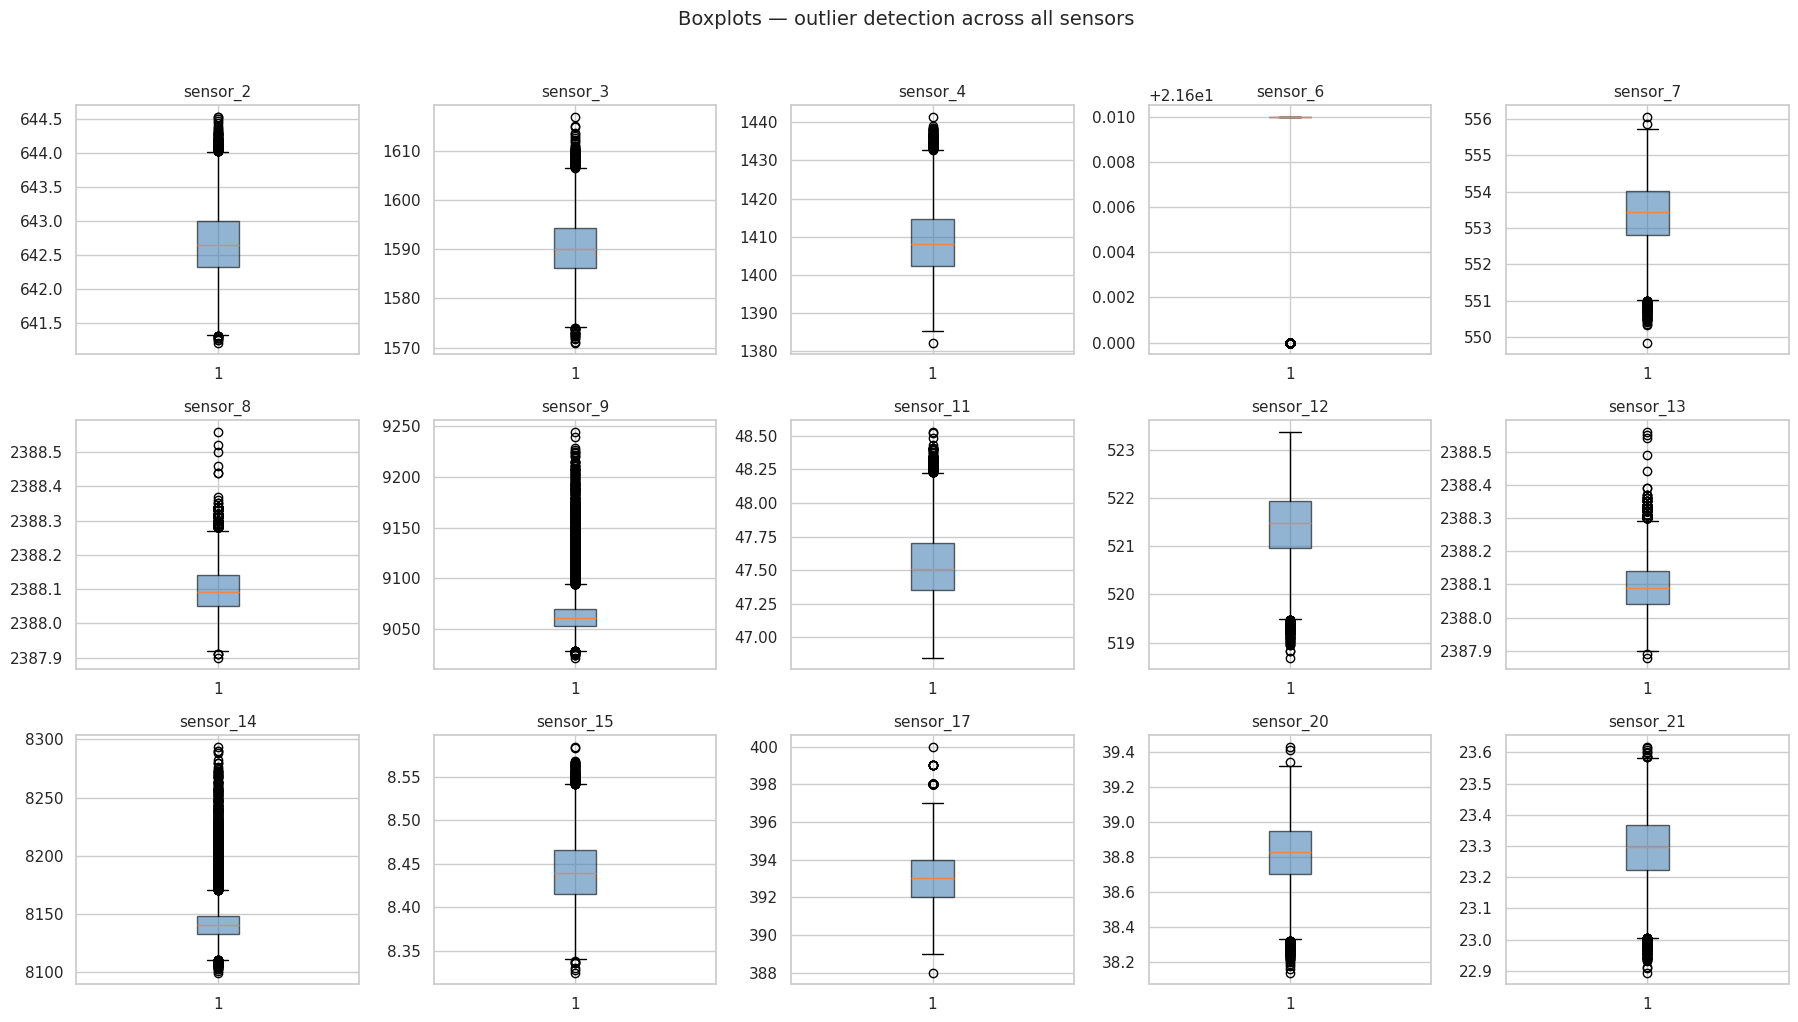

Plot saved!


In [14]:
# Plot boxplots for all 15 sensors
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, sensor in enumerate(sensor_cols_useful):
    axes[i].boxplot(train_df[sensor].dropna(),
                    patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(sensor, fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Boxplots — outlier detection across all sensors', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plot4_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

 Z-score outlier flagging
Concept: Z-score tells you how many standard deviations a value is away from the mean. A z-score of 0 means exactly average. A z-score of 3 means the value is 3 standard deviations above average — that's unusual. We flag anything beyond ±3 as an outlier.
This is also your statistical analysis section — it demonstrates mean, std, and z-score normalization knowledge all in one cell.

In [15]:
from scipy import stats

print("=== Z-score outlier analysis ===\n")

outlier_summary = []

for sensor in sensor_cols_useful:
    # Calculate z-score for every reading of this sensor
    z_scores = np.abs(stats.zscore(train_df[sensor]))

    # Count how many readings have z-score > 3
    n_outliers = (z_scores > 3).sum()
    pct = (n_outliers / len(train_df)) * 100

    outlier_summary.append({
        'sensor'    : sensor,
        'mean'      : train_df[sensor].mean(),
        'std'       : train_df[sensor].std(),
        'n_outliers': n_outliers,
        'pct'       : pct
    })

# Display as a clean table
outlier_df = pd.DataFrame(outlier_summary)
outlier_df = outlier_df.sort_values('pct', ascending=False)
print(outlier_df.round(3).to_string(index=False))

print(f"\nTotal outlier readings across all sensors: {outlier_df['n_outliers'].sum()}")
print("Note: CMAPSS outliers are real sensor variation, not errors — we keep them.")

=== Z-score outlier analysis ===

   sensor     mean    std  n_outliers   pct
 sensor_9 9065.243 22.083         521 2.525
sensor_14 8143.753 19.076         496 2.404
 sensor_6   21.610  0.001         406 1.968
 sensor_8 2388.097  0.071         107 0.519
sensor_13 2388.096  0.072          83 0.402
sensor_17  393.211  1.549          81 0.393
 sensor_3 1590.523  6.131          47 0.228
sensor_20   38.816  0.181          43 0.208
 sensor_4 1408.934  9.001          36 0.174
sensor_21   23.290  0.108          34 0.165
 sensor_7  553.368  0.885          34 0.165
sensor_12  521.413  0.738          34 0.165
sensor_15    8.442  0.038          33 0.160
 sensor_2  642.681  0.500          31 0.150
sensor_11   47.541  0.267          23 0.111

Total outlier readings across all sensors: 2009
Note: CMAPSS outliers are real sensor variation, not errors — we keep them.


"EDA revealed clear degradation signatures in the sensor data. Sensors 4, 11, and 15 show consistent upward trends with engine age, consistent with rising exhaust gas temperatures as turbine efficiency degrades. Sensors 7, 12, 20 and 21 show downward trends, consistent with declining fan speed and pressure ratios as mechanical wear increases. Sensor_6 showed near-zero correlation with cycle (r = 0.11) and was excluded from modeling. Strong inter-sensor correlations suggest some redundancy in the 15-sensor set."



## 4. Feature Engineering

Three transformations are applied to prepare the data for modelling:

1. **RUL label creation** — target variable computed as max_cycle minus current cycle,
   capped at 125 cycles (piecewise-linear approach) to focus the model on the degradation zone
2. **Rolling average features** — 5-cycle rolling means applied to 7 key sensors to
   smooth measurement noise and expose underlying degradation trends
3. **Z-score normalisation** — all features scaled to zero mean and unit variance.
   The scaler is fitted on training data only to prevent data leakage.

In [16]:
# Drop sensor_6 from both train and test
train_df = train_df.drop(columns=['sensor_6'])
test_df  = test_df.drop(columns=['sensor_6'])

# Update our useful sensor list
useful_sensors = [s for s in useful_sensors if s != 'sensor_6']

print(f"Sensors after dropping sensor_6: {len(useful_sensors)}")
print(useful_sensors)
# Should now show 14 sensors

Sensors after dropping sensor_6: 14
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


Create the RUL column (training set)
Concept — explained simply:
Imagine engine 1 lives for 192 cycles total. At cycle 1, it has 191 cycles remaining. At cycle 100, it has 92 remaining. At cycle 192, it has 0 remaining — it just failed.
So: RUL = max_cycle_for_that_engine − current_cycle
We also apply a cap of 125 cycles. Why? Because a brand new engine and an engine that has done 50 cycles are both equally "healthy" — we don't need to distinguish between them. Capping RUL at 125 tells the model: "anything above 125 cycles remaining — treat as equally healthy." This is standard practice in CMAPSS research and makes the model focus on the degradation zone.

In [17]:
# Step 1: find the maximum cycle for each engine (its total lifetime)
max_cycles = train_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']

print("Sample of max cycles per engine:")
print(max_cycles.head(10))

Sample of max cycles per engine:
   engine_id  max_cycle
0          1        192
1          2        287
2          3        179
3          4        189
4          5        269
5          6        188
6          7        259
7          8        150
8          9        201
9         10        222


In [18]:
# Step 2: merge max_cycle back into the main dataframe
train_df = train_df.merge(max_cycles, on='engine_id', how='left')

# Step 3: calculate raw RUL
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']

# Step 4: apply the cap — anything above 125 becomes 125
RUL_CAP = 125
train_df['RUL'] = train_df['RUL'].clip(upper=RUL_CAP)

# Step 5: drop the max_cycle column — we don't need it anymore
train_df = train_df.drop(columns=['max_cycle'])

print("=== RUL column created ===")
print(train_df[['engine_id', 'cycle', 'RUL']].head(15))
print(f"\nRUL range: {train_df['RUL'].min()} to {train_df['RUL'].max()}")
print(f"Rows where RUL = 125 (capped): {(train_df['RUL'] == 125).sum()}")

=== RUL column created ===
    engine_id  cycle  RUL
0           1      1  125
1           1      2  125
2           1      3  125
3           1      4  125
4           1      5  125
5           1      6  125
6           1      7  125
7           1      8  125
8           1      9  125
9           1     10  125
10          1     11  125
11          1     12  125
12          1     13  125
13          1     14  125
14          1     15  125

RUL range: 0 to 125
Rows where RUL = 125 (capped): 8131


Visualise the RUL column:
This confirms the cap worked and shows the distribution of RUL values.

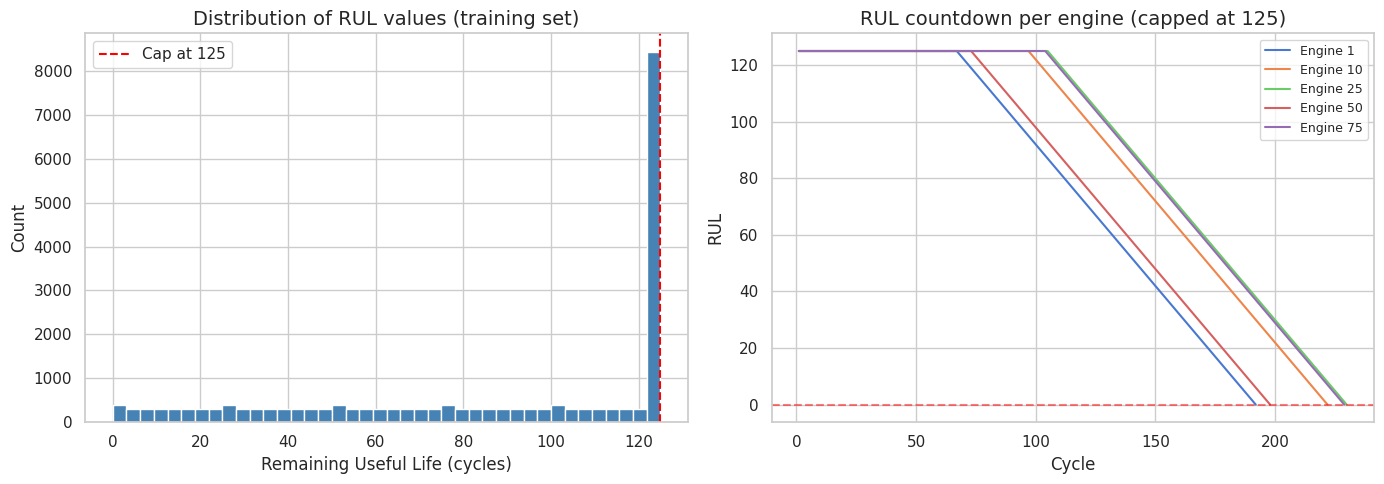

Plot saved!


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: RUL distribution
axes[0].hist(train_df['RUL'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(125, color='red', linestyle='--', label='Cap at 125')
axes[0].set_title('Distribution of RUL values (training set)')
axes[0].set_xlabel('Remaining Useful Life (cycles)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Plot 2: RUL over cycles for 5 engines — should see countdown to 0
sample_engines = [1, 10, 25, 50, 75]
for eid in sample_engines:
    edata = train_df[train_df['engine_id'] == eid]
    axes[1].plot(edata['cycle'], edata['RUL'], label=f'Engine {eid}', linewidth=1.5)

axes[1].set_title('RUL countdown per engine (capped at 125)')
axes[1].set_xlabel('Cycle')
axes[1].set_ylabel('RUL')
axes[1].legend(fontsize=9)
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5, label='Failure')

plt.tight_layout()
plt.savefig('plot5_RUL_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

Rolling average features
Concept: Look back at your sensor trend plots — they were noisy, right? Each cycle's reading jumps up and down slightly even within a general trend. A rolling average smooths this out by replacing each reading with the average of the last 5 cycles. It's like calculating a moving average in stock price charts.
This demonstrates your time series knowledge and also genuinely helps the model learn cleaner patterns.

In [20]:
# We'll create rolling mean features for our top degrading sensors
# Window of 5 cycles — average of current + previous 4 readings

top_sensors = ['sensor_4', 'sensor_7', 'sensor_11', 'sensor_12',
               'sensor_15', 'sensor_20', 'sensor_21']

for sensor in top_sensors:
    col_name = f'{sensor}_roll5'

    # Important: groupby engine_id first — rolling should be within each engine, not across engines
    train_df[col_name] = (train_df.groupby('engine_id')[sensor]
                          .transform(lambda x: x.rolling(window=5, min_periods=1).mean()))

    test_df[col_name]  = (test_df.groupby('engine_id')[sensor]
                          .transform(lambda x: x.rolling(window=5, min_periods=1).mean()))

print("=== Rolling average features created ===")
new_cols = [f'{s}_roll5' for s in top_sensors]
print(train_df[['engine_id', 'cycle'] + new_cols].head(10))

=== Rolling average features created ===
   engine_id  cycle  sensor_4_roll5  sensor_7_roll5  sensor_11_roll5  \
0          1      1     1400.600000      554.360000           47.470   
1          1      2     1401.870000      554.055000           47.480   
2          1      3     1402.646667      554.123333           47.410   
3          1      4     1402.452500      554.205000           47.340   
4          1      5     1403.206000      554.164000           47.328   
5          1      6     1402.760000      554.226000           47.266   
6          1      7     1401.686000      554.344000           47.240   
7          1      8     1401.040000      554.262000           47.234   
8          1      9     1399.626000      554.110000           47.266   
9          1     10     1398.474000      554.028000           47.216   

   sensor_12_roll5  sensor_15_roll5  sensor_20_roll5  sensor_21_roll5  
0          521.660         8.419500        39.060000        23.419000  
1          521.970    

RESULT: What min_periods=1 means: For the first few cycles of an engine, there aren't 5 previous readings yet. min_periods=1 tells pandas to still calculate an average using however many readings are available — so cycle 1 uses 1 reading, cycle 2 uses 2, cycle 3 uses 3, etc. Without this, the first 4 rows per engine would be NaN.

 Z-score normalization
Concept: Right now sensor_2 has values around 642 and sensor_15 has values around 8.4. These are completely different scales. A machine learning model would think sensor_2 is more "important" just because its numbers are bigger — which is wrong.
Z-score normalization rescales every sensor to the same scale:

Mean of 0
Standard deviation of 1

Formula: z = (value − mean) / std
A reading of z = 2 means "this reading is 2 standard deviations above average for this sensor." Now all sensors are comparable.

In [21]:
from sklearn.preprocessing import StandardScaler

# Define all feature columns we'll use for modeling
# Original sensors + rolling features (excluding engine_id, cycle, RUL, op_settings)
feature_cols = useful_sensors + [f'{s}_roll5' for s in top_sensors]
# Remove sensor_6 just in case
feature_cols = [c for c in feature_cols if 'sensor_6' not in c]

print(f"Total features before normalization: {len(feature_cols)}")
print(feature_cols)

Total features before normalization: 21
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'sensor_4_roll5', 'sensor_7_roll5', 'sensor_11_roll5', 'sensor_12_roll5', 'sensor_15_roll5', 'sensor_20_roll5', 'sensor_21_roll5']


In [22]:
# Fit the scaler on training data ONLY — very important
# Never fit on test data — that would be "cheating" (data leakage)
scaler = StandardScaler()

# Fit and transform training features
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])

# Only transform test data (use the same scale learned from training)
test_df[feature_cols]  = scaler.transform(test_df[feature_cols])

print("=== Normalization complete ===")
print("\nTraining data — sensor means after normalization (should be ~0):")
print(train_df[feature_cols].mean().round(4))
print("\nTraining data — sensor stds after normalization (should be ~1):")
print(train_df[feature_cols].std().round(4))

=== Normalization complete ===

Training data — sensor means after normalization (should be ~0):
sensor_2           0.0
sensor_3          -0.0
sensor_4           0.0
sensor_7          -0.0
sensor_8           0.0
sensor_9          -0.0
sensor_11         -0.0
sensor_12         -0.0
sensor_13          0.0
sensor_14          0.0
sensor_15         -0.0
sensor_17          0.0
sensor_20          0.0
sensor_21          0.0
sensor_4_roll5    -0.0
sensor_7_roll5     0.0
sensor_11_roll5   -0.0
sensor_12_roll5   -0.0
sensor_15_roll5   -0.0
sensor_20_roll5   -0.0
sensor_21_roll5   -0.0
dtype: float64

Training data — sensor stds after normalization (should be ~1):
sensor_2           1.0
sensor_3           1.0
sensor_4           1.0
sensor_7           1.0
sensor_8           1.0
sensor_9           1.0
sensor_11          1.0
sensor_12          1.0
sensor_13          1.0
sensor_14          1.0
sensor_15          1.0
sensor_17          1.0
sensor_20          1.0
sensor_21          1.0
sensor_4_roll5    

Critical point to understand:
We fit the scaler on training data only, then apply the same transformation to test data. Why? Because in real life, when a new engine comes in, you don't know its future readings. You use the scale learned from historical data. Fitting on test data would be data leakage — your model would be "peeking" at test information during training, giving artificially good results.

In [23]:
print("=== Final dataframe summary after feature engineering ===")
print(f"Training shape : {train_df.shape}")
print(f"Test shape     : {test_df.shape}")
print(f"Feature columns: {len(feature_cols)}")
print(f"\nColumns in training data:")
print(list(train_df.columns))
print(f"\nRUL stats:")
print(train_df['RUL'].describe().round(2))

=== Final dataframe summary after feature engineering ===
Training shape : (20631, 27)
Test shape     : (13096, 26)
Feature columns: 21

Columns in training data:
['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'RUL', 'sensor_4_roll5', 'sensor_7_roll5', 'sensor_11_roll5', 'sensor_12_roll5', 'sensor_15_roll5', 'sensor_20_roll5', 'sensor_21_roll5']

RUL stats:
count    20631.00
mean        86.83
std         41.67
min          0.00
25%         51.00
50%        103.00
75%        125.00
max        125.00
Name: RUL, dtype: float64


## 5. Regression Modelling — RUL Prediction

Two models are trained to predict RUL from normalised sensor readings:

- **Linear Regression** — baseline model assuming a linear relationship between
  sensor readings and RUL
- **Random Forest Regressor** — ensemble of 100 decision trees capturing
  non-linear degradation patterns

Models are evaluated using RMSE (Root Mean Squared Error) and MAE (Mean Absolute Error)
on the test set. The test set uses each engine's final sensor snapshot as input,
with true RUL provided by RUL_FD001.txt.

 Prepare X and y (inputs and target)

Concept: Machine learning models need two things clearly separated:

X = the input features (sensor readings) — what the model sees
y = the target (RUL) — what the model learns to predict

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# X = all 21 feature columns (normalized sensors + rolling averages)
X_train = train_df[feature_cols]
y_train = train_df['RUL']

print("=== Training data ready ===")
print(f"X_train shape : {X_train.shape}  (rows, features)")
print(f"y_train shape : {y_train.shape}  (rows,)")
print(f"\nFirst 3 rows of X_train:")
print(X_train.head(3).round(3))
print(f"\nFirst 3 RUL values:")
print(y_train.head(3).values)

=== Training data ready ===
X_train shape : (20631, 21)  (rows, features)
y_train shape : (20631,)  (rows,)

First 3 rows of X_train:
   sensor_2  sensor_3  sensor_4  sensor_7  sensor_8  sensor_9  sensor_11  \
0    -1.722    -0.134    -0.926     1.121    -0.516    -0.863     -0.266   
1    -1.062     0.212    -0.644     0.432    -0.798    -0.959     -0.192   
2    -0.662    -0.413    -0.526     1.008    -0.235    -0.557     -1.015   

   sensor_12  sensor_13  sensor_14  ...  sensor_17  sensor_20  sensor_21  \
0      0.334     -1.059     -0.269  ...     -0.782      1.348      1.194   
1      1.175     -0.364     -0.643  ...     -0.782      1.017      1.237   
2      1.365     -0.920     -0.552  ...     -2.073      0.740      0.503   

   sensor_4_roll5  sensor_7_roll5  sensor_11_roll5  sensor_12_roll5  \
0          -1.005           1.228           -0.258            0.337   
1          -0.847           0.841           -0.218            0.800   
2          -0.750           0.928          

 Prepare the test set
Concept: The test set works differently in CMAPSS. Each engine in the test file is shown up to a certain cycle, then cut off. We take the last row of each engine (its most recent reading) and predict RUL from there. The true RUL for that moment is in RUL_FD001.txt — which we loaded as rul_df.

In [25]:
# Take the last row of each engine in test set
# This represents the most recent sensor snapshot before the cut-off
X_test = test_df.groupby('engine_id')[feature_cols].last().reset_index(drop=True)

# True RUL values from the RUL file — cap these at 125 too for consistency
y_test = rul_df['true_rul'].clip(upper=125)

print("=== Test data ready ===")
print(f"X_test shape : {X_test.shape}  (one row per engine)")
print(f"y_test shape : {y_test.shape}  (one true RUL per engine)")
print(f"\nTrue RUL sample (first 10 engines):")
print(y_test.values[:10])
print(f"\nTrue RUL range: {y_test.min()} to {y_test.max()}")

=== Test data ready ===
X_test shape : (100, 21)  (one row per engine)
y_test shape : (100,)  (one true RUL per engine)

True RUL sample (first 10 engines):
[112  98  69  82  91  93  91  95 111  96]

True RUL range: 7 to 125


Train Linear Regression
Concept: Linear Regression assumes RUL is a weighted sum of all sensor readings. It learns one weight (coefficient) per feature — sensors with bigger weights matter more. It's the simplest possible model and acts as our baseline — if a fancier model can't beat this, something is wrong.

In [26]:
# Train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on test set
lr_preds = lr_model.predict(X_test)

# Clip predictions to valid range — RUL can't be negative or above 125
lr_preds = np.clip(lr_preds, 0, 125)

# Calculate error metrics
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae  = mean_absolute_error(y_test, lr_preds)

print("=== Linear Regression Results ===")
print(f"RMSE : {lr_rmse:.2f} cycles")
print(f"MAE  : {lr_mae:.2f} cycles")
print(f"\nWhat this means:")
print(f"On average, predictions are off by ~{lr_mae:.0f} cycles from true RUL")

=== Linear Regression Results ===
RMSE : 20.92 cycles
MAE  : 16.39 cycles

What this means:
On average, predictions are off by ~16 cycles from true RUL


What RMSE and MAE mean in plain language:

MAE (Mean Absolute Error): average prediction error in cycles. MAE = 25 means on average your predictions are 25 cycles off.
RMSE (Root Mean Squared Error): similar but penalises large errors more heavily. Always ≥ MAE. The gap between RMSE and MAE tells you how many large errors exist.

 Train Random Forest
Concept: Random Forest builds hundreds of decision trees, each trained on a random subset of your data and features. Each tree votes on a prediction, and the final answer is the average of all votes. This handles non-linear relationships that Linear Regression can't capture — like "sensor_11 only becomes predictive after cycle 100."

In [27]:
# Train Random Forest
# n_estimators=100 means 100 trees
# random_state=42 means results are reproducible (same result every run)
rf_model = RandomForestRegressor(n_estimators=100,
                                  random_state=42,
                                  n_jobs=-1)       # use all CPU cores to speed up

print("Training Random Forest (may take 20-30 seconds)...")
rf_model.fit(X_train, y_train)

# Predict on test set
rf_preds = rf_model.predict(X_test)
rf_preds = np.clip(rf_preds, 0, 125)

# Calculate error metrics
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae  = mean_absolute_error(y_test, rf_preds)

print("=== Random Forest Results ===")
print(f"RMSE : {rf_rmse:.2f} cycles")
print(f"MAE  : {rf_mae:.2f} cycles")
print(f"\nWhat this means:")
print(f"On average, predictions are off by ~{rf_mae:.0f} cycles from true RUL")

Training Random Forest (may take 20-30 seconds)...
=== Random Forest Results ===
RMSE : 17.97 cycles
MAE  : 12.74 cycles

What this means:
On average, predictions are off by ~13 cycles from true RUL


Compare both models

In [28]:
print("=" * 45)
print(f"{'Model':<25} {'RMSE':>8} {'MAE':>8}")
print("=" * 45)
print(f"{'Linear Regression':<25} {lr_rmse:>8.2f} {lr_mae:>8.2f}")
print(f"{'Random Forest':<25} {rf_rmse:>8.2f} {rf_mae:>8.2f}")
print("=" * 45)

improvement = ((lr_rmse - rf_rmse) / lr_rmse) * 100
print(f"\nRandom Forest improves RMSE by {improvement:.1f}% over Linear Regression")

Model                         RMSE      MAE
Linear Regression            20.92    16.39
Random Forest                17.97    12.74

Random Forest improves RMSE by 14.1% over Linear Regression


Visualize predictions vs actual RUL
Why this plot matters: Numbers alone don't tell the whole story. A scatter plot of predicted vs actual RUL shows you where the model is wrong. A perfect model would put every dot exactly on the diagonal line. Dots above the line = over-predicting (model thinks engine is healthier than it is — dangerous in real life). Dots below = under-predicting (model is overly pessimistic).

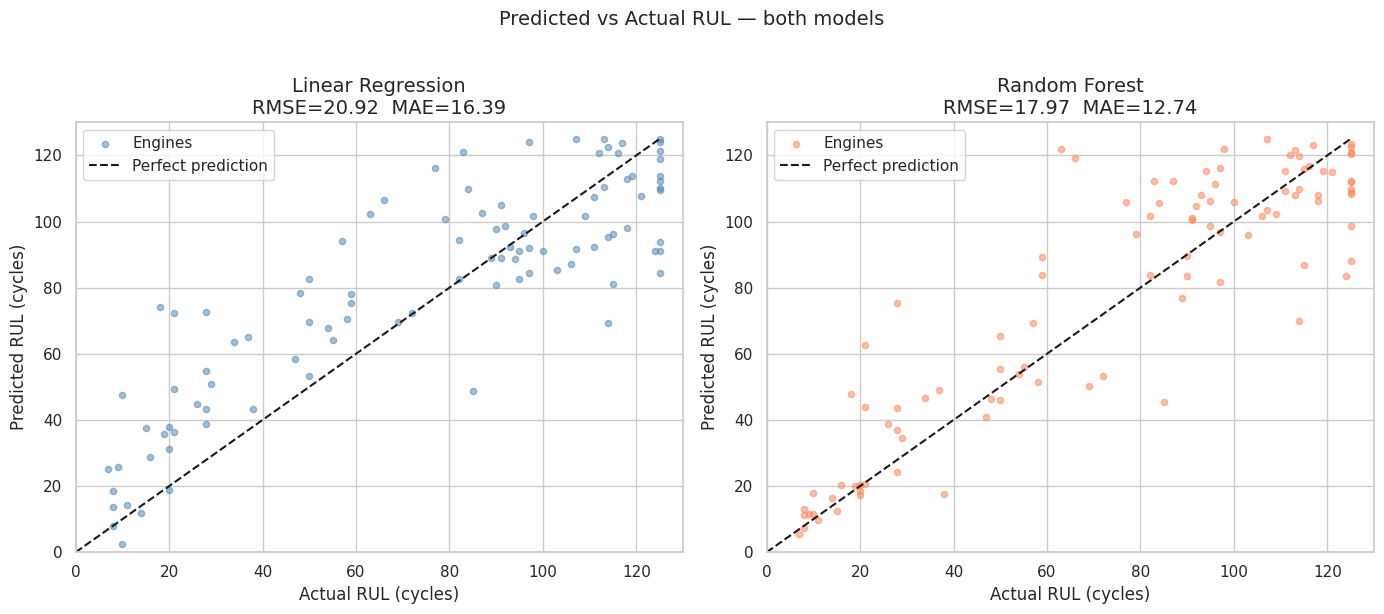

Plot saved!


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, preds, title, color in zip(
    axes,
    [lr_preds, rf_preds],
    ['Linear Regression', 'Random Forest'],
    ['steelblue', 'coral']
):
    ax.scatter(y_test, preds, alpha=0.5, color=color, s=20, label='Engines')

    # Perfect prediction line
    ax.plot([0, 125], [0, 125], 'k--', linewidth=1.5, label='Perfect prediction')

    # Labels
    ax.set_xlabel('Actual RUL (cycles)')
    ax.set_ylabel('Predicted RUL (cycles)')
    ax.set_title(f'{title}\nRMSE={np.sqrt(mean_squared_error(y_test, preds)):.2f}  MAE={mean_absolute_error(y_test, preds):.2f}')
    ax.legend()
    ax.set_xlim(0, 130)
    ax.set_ylim(0, 130)

plt.suptitle('Predicted vs Actual RUL — both models', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plot6_predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

Feature importance (Random Forest bonus)
Concept: Random Forest can tell you which features it relied on most. This is called feature importance. This is a great slide for your report — it connects your EDA findings (sensors with strong trends) to your model's findings (same sensors are most important).

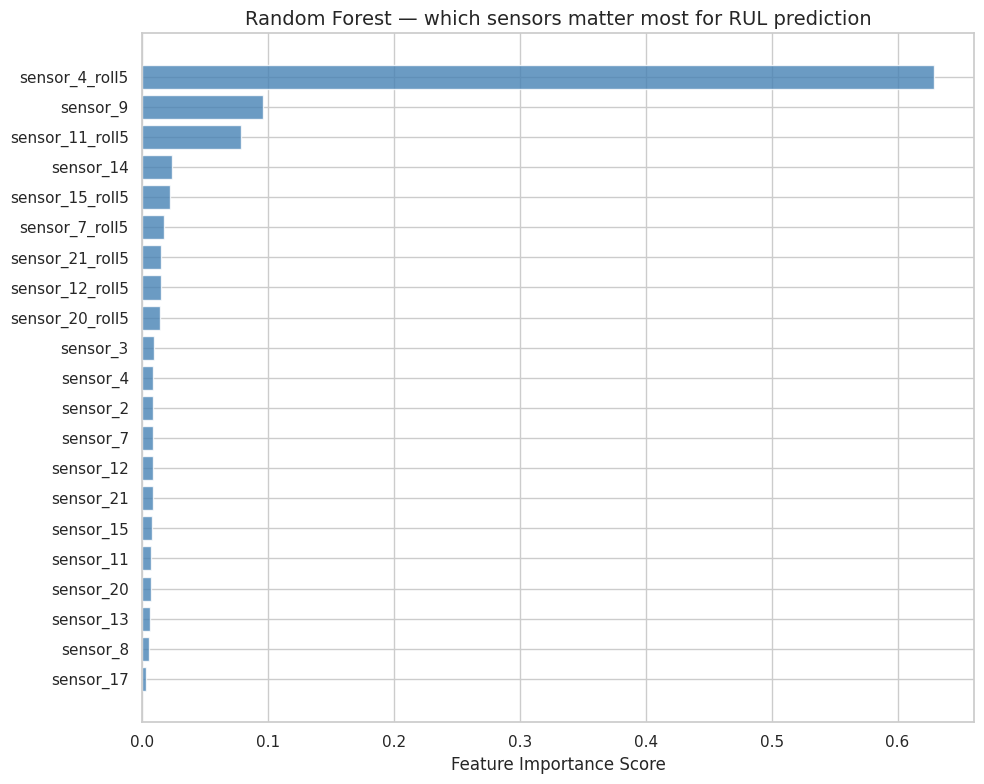


Top 5 most important features:
sensor_4_roll5     0.629285
sensor_9           0.096038
sensor_11_roll5    0.078813
sensor_14          0.023635
sensor_15_roll5    0.022055
dtype: float64


In [30]:
# Get feature importances from the trained Random Forest
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)  # ascending for horizontal bar

plt.figure(figsize=(10, 8))
bars = plt.barh(range(len(importances)), importances.values, color='steelblue', alpha=0.8)
plt.yticks(range(len(importances)), importances.index)
plt.xlabel('Feature Importance Score')
plt.title('Random Forest — which sensors matter most for RUL prediction')
plt.tight_layout()
plt.savefig('plot7_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 most important features:")
print(importances.sort_values(ascending=False).head(5))

What REGRESSION MODELLING deliverED



✅ Linear Regression trained and evaluated
✅ Random Forest trained and evaluated
✅ Both compared with RMSE and MAE
✅ Predicted vs actual scatter plots
✅ Feature importance plot connecting EDA to modeling

## 6. Degradation Clustering — K-Means Analysis

Beyond predicting when an engine will fail, we investigate *how* engines degrade.
K-Means clustering is applied to each engine's mean sensor readings during its
final 20 cycles — its degradation fingerprint.

The elbow method is used to select k=3 clusters. PCA reduces the 14-dimensional
sensor space to 2D for visualisation while preserving maximum variance.

 Build the degradation profile per engine

---



Concept: We need one row per engine that summarises its degradation behaviour. We do this by taking the mean sensor readings from the last 20 cycles of each engine — the period closest to failure. This captures each engine's degradation fingerprint.

In [31]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# For clustering we use the ORIGINAL (non-normalized) train_df won't work
# since we already normalized it — that's actually fine and better for clustering
# We'll use the normalized sensor values from the last 20 cycles of each engine

# Step 1: get the last 20 cycles for each engine
def get_last_n_cycles(df, n=20):
    return df.groupby('engine_id').apply(
        lambda x: x.nlargest(n, 'cycle')
    ).reset_index(drop=True)

last20 = get_last_n_cycles(train_df, n=20)

# Step 2: compute mean of each sensor over those last 20 cycles per engine
degradation_profile = last20.groupby('engine_id')[useful_sensors].mean()

# Step 3: also record the engine's total lifetime (useful for interpretation later)
engine_lifetimes = train_df.groupby('engine_id')['cycle'].max()
degradation_profile['lifetime'] = engine_lifetimes

print("=== Degradation profile (one row per engine) ===")
print(f"Shape: {degradation_profile.shape}")
print(degradation_profile.head())

=== Degradation profile (one row per engine) ===
Shape: (100, 15)
           sensor_2  sensor_3  sensor_4  sensor_7  sensor_8  sensor_9  \
engine_id                                                               
1          1.611000  1.379038  1.756282 -1.879184  2.195550 -1.019545   
2          1.803984  1.583980  1.860167 -1.854893  1.406637  1.228473   
3          1.327024  1.659090  1.513848 -1.084333  0.307794  4.426163   
4          1.626999  1.998920  1.722895 -1.416510  0.462759  4.472558   
5          1.745989  1.949581  1.895276 -1.728914  0.695206  3.243476   

           sensor_11  sensor_12  sensor_13  sensor_14  sensor_15  sensor_17  \
engine_id                                                                     
1           1.903288  -1.891394   2.187900  -1.348847   1.532482   1.445928   
2           2.049311  -1.978169   1.311893   1.083329   1.939771   1.671921   
3           1.463346  -1.088720   0.262074   4.408342   1.507552   1.413644   
4           1.581288  -1.40

Elbow plot to choose number of clusters (k)
Concept: K-Means needs you to tell it how many clusters to make. But how do we know the right number? We use the elbow method — we run K-Means with k = 1, 2, 3... up to 10, and plot the inertia (how compact the clusters are). The plot looks like an arm — where it "bends" like an elbow is the best k.

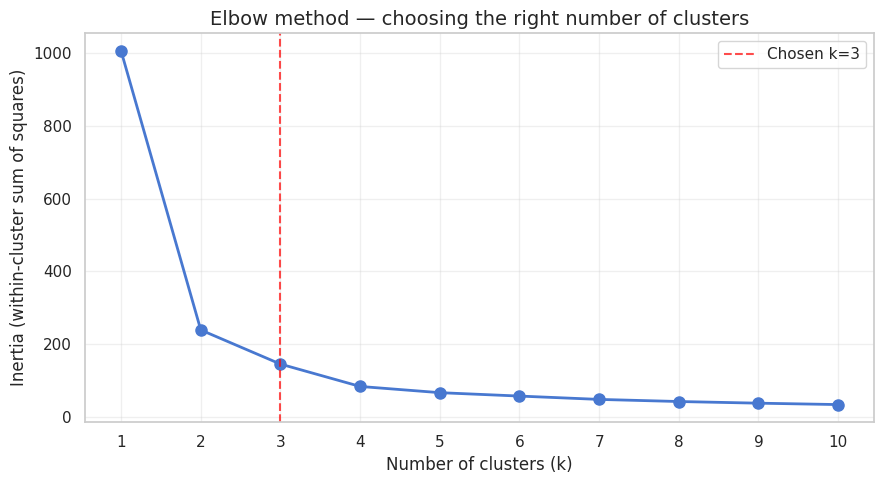

Plot saved!


In [32]:
# Use only sensor columns for clustering (not lifetime — that would be cheating)
cluster_features = useful_sensors

inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(degradation_profile[cluster_features])
    inertias.append(km.inertia_)

# Plot the elbow curve
plt.figure(figsize=(9, 5))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow method — choosing the right number of clusters')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)

# Annotate the elbow
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Chosen k=3')
plt.legend()
plt.tight_layout()
plt.savefig('plot8_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

The curve drops sharply at first then flattens. The elbow — where it stops dropping steeply — is your best k. For FD001 it typically falls at k=3, giving us: fast degraders, medium degraders, slow degraders.

 Fit K-Means with k=3

In [33]:
# Fit K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
degradation_profile['cluster'] = kmeans.fit_predict(
    degradation_profile[cluster_features]
)

# Check how many engines in each cluster
cluster_counts = degradation_profile['cluster'].value_counts().sort_index()
print("=== Engines per cluster ===")
print(cluster_counts)

# Check average lifetime per cluster — this tells us which cluster degrades fastest
cluster_summary = degradation_profile.groupby('cluster')['lifetime'].agg(['mean', 'min', 'max', 'count'])
cluster_summary.columns = ['avg_lifetime', 'min_lifetime', 'max_lifetime', 'n_engines']
cluster_summary = cluster_summary.sort_values('avg_lifetime')

print("\n=== Cluster summary ===")
print(cluster_summary.round(1))

=== Engines per cluster ===
cluster
0    46
1    30
2    24
Name: count, dtype: int64

=== Cluster summary ===
         avg_lifetime  min_lifetime  max_lifetime  n_engines
cluster                                                     
0               194.5           128           362         46
1               215.2           156           341         30
2               217.9           137           313         24


One cluster will have noticeably shorter average lifetimes (fast degraders), one in the middle, one with longer lifetimes (slow degraders).

Label the clusters meaningfully

In [34]:
# Sort by average lifetime to assign meaningful labels
# Cluster with shortest avg lifetime = fast degraders
sorted_clusters = cluster_summary.sort_values('avg_lifetime').index.tolist()

label_map = {
    sorted_clusters[0]: 'Fast degraders',
    sorted_clusters[1]: 'Medium degraders',
    sorted_clusters[2]: 'Slow degraders'
}

degradation_profile['degradation_type'] = degradation_profile['cluster'].map(label_map)

print("=== Cluster labels assigned ===")
print(degradation_profile['degradation_type'].value_counts())
print("\nSample:")
print(degradation_profile[['lifetime', 'cluster', 'degradation_type']].head(10))

=== Cluster labels assigned ===
degradation_type
Fast degraders      46
Medium degraders    30
Slow degraders      24
Name: count, dtype: int64

Sample:
           lifetime  cluster  degradation_type
engine_id                                     
1               192        0    Fast degraders
2               287        2    Slow degraders
3               179        1  Medium degraders
4               189        1  Medium degraders
5               269        1  Medium degraders
6               188        0    Fast degraders
7               259        2    Slow degraders
8               150        0    Fast degraders
9               201        1  Medium degraders
10              222        2    Slow degraders


Visualise clusters with PCA
Concept: We have 14 sensor dimensions — impossible to plot directly. PCA (Principal Component Analysis) reduces them to 2 dimensions while keeping as much information as possible. Think of it like compressing a 3D object into a 2D shadow — you lose some detail but can still see the overall shape.
We use PCA only for visualisation — the clustering itself was done in full 14-dimensional space.

PCA variance explained: 96.1% + 1.8% = 97.9% total


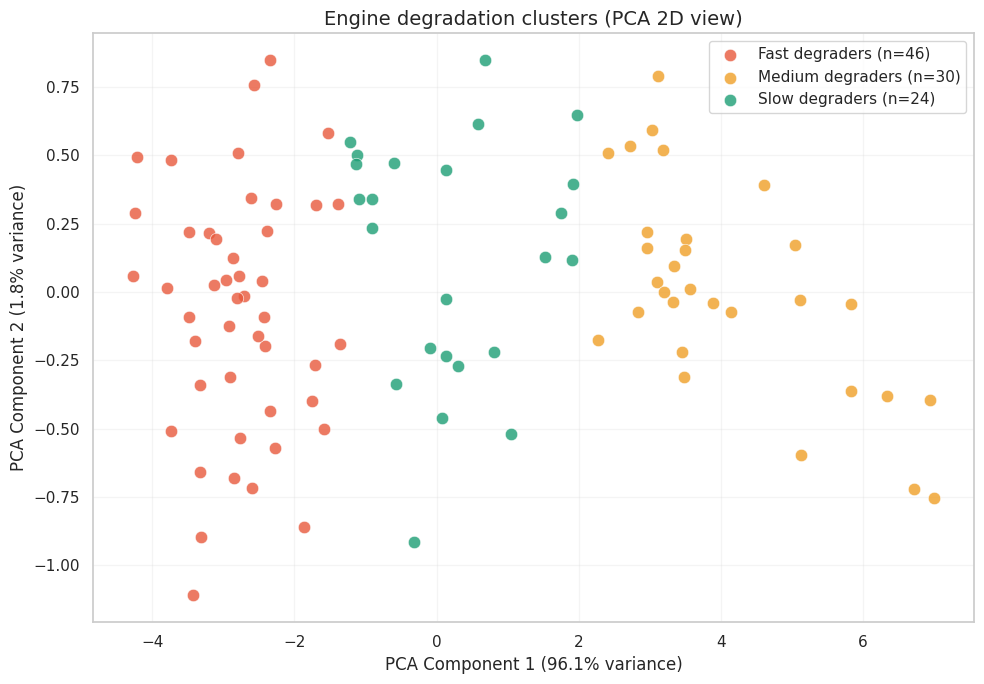

Plot saved!


In [35]:
# Reduce to 2D for visualization
pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(degradation_profile[cluster_features])

degradation_profile['pca_1'] = coords_2d[:, 0]
degradation_profile['pca_2'] = coords_2d[:, 1]

# Variance explained — how much information the 2D view preserves
var_explained = pca.explained_variance_ratio_ * 100
print(f"PCA variance explained: {var_explained[0]:.1f}% + {var_explained[1]:.1f}% = {sum(var_explained):.1f}% total")

# Plot
colors = {'Fast degraders': '#E8593C',
           'Medium degraders': '#EF9F27',
           'Slow degraders': '#1D9E75'}

plt.figure(figsize=(10, 7))

for label, color in colors.items():
    mask = degradation_profile['degradation_type'] == label
    subset = degradation_profile[mask]
    plt.scatter(subset['pca_1'], subset['pca_2'],
                c=color, label=f"{label} (n={mask.sum()})",
                s=80, alpha=0.8, edgecolors='white', linewidth=0.5)

plt.xlabel(f'PCA Component 1 ({var_explained[0]:.1f}% variance)')
plt.ylabel(f'PCA Component 2 ({var_explained[1]:.1f}% variance)')
plt.title('Engine degradation clusters (PCA 2D view)')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('plot9_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

Cluster lifetime distribution (final clustering plot): it directly shows the practical meaning of each cluster.

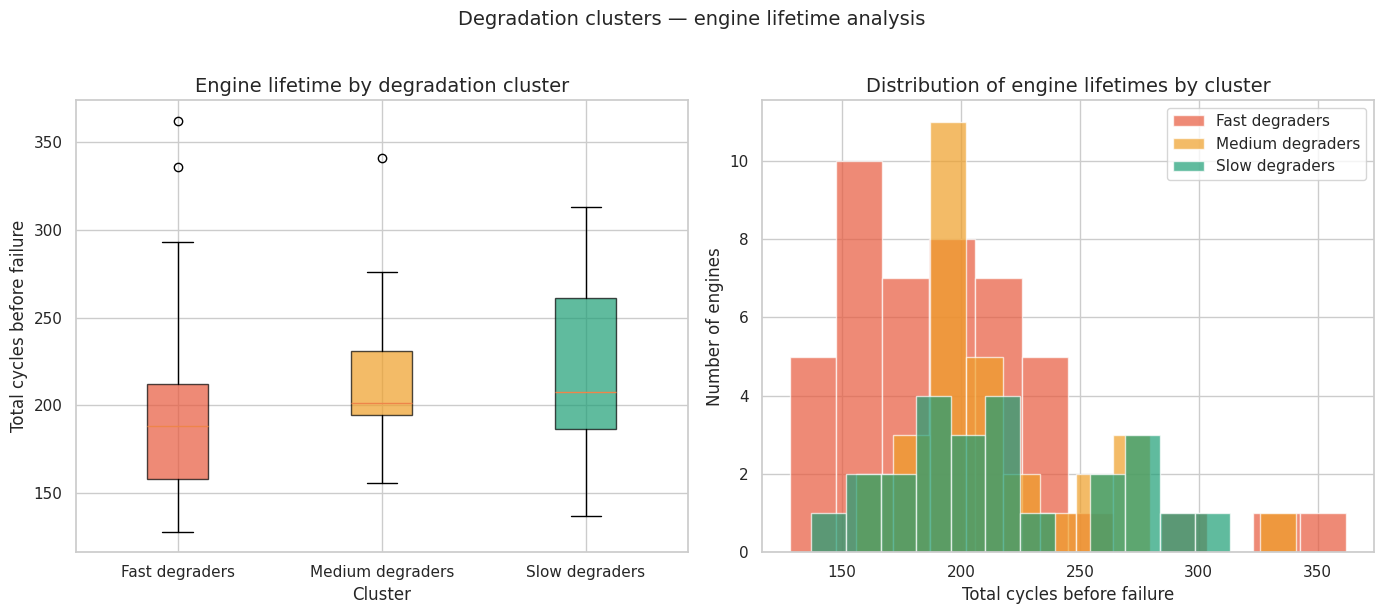

Plot saved!


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: boxplot of lifetimes per cluster
cluster_order = ['Fast degraders', 'Medium degraders', 'Slow degraders']
cluster_colors = ['#E8593C', '#EF9F27', '#1D9E75']

data_to_plot = [
    degradation_profile[degradation_profile['degradation_type'] == c]['lifetime'].values
    for c in cluster_order
]

bp = axes[0].boxplot(data_to_plot, patch_artist=True, labels=cluster_order)
for patch, color in zip(bp['boxes'], cluster_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_title('Engine lifetime by degradation cluster')
axes[0].set_ylabel('Total cycles before failure')
axes[0].set_xlabel('Cluster')

# Plot 2: histogram of lifetimes coloured by cluster
for label, color in zip(cluster_order, cluster_colors):
    subset = degradation_profile[degradation_profile['degradation_type'] == label]
    axes[1].hist(subset['lifetime'], bins=12, color=color,
                 alpha=0.7, label=label, edgecolor='white')

axes[1].set_title('Distribution of engine lifetimes by cluster')
axes[1].set_xlabel('Total cycles before failure')
axes[1].set_ylabel('Number of engines')
axes[1].legend()

plt.suptitle('Degradation clusters — engine lifetime analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plot10_cluster_lifetimes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

What Clustering delivers

✅ Elbow plot justifying k=3
✅ K-Means fitted on degradation fingerprints
✅ Clusters labelled: fast / medium / slow degraders
✅ PCA scatter plot visualising cluster separation
✅ Lifetime boxplot showing real-world meaning of each cluster

## 7. Conclusions

### Key findings

**Data & EDA:**  
- FD001 contains 100 engines with lifetimes ranging from 128 to 362 cycles (mean ~206 cycles)
- 14 of 21 sensors carry useful degradation signal; sensor_6 was excluded (std = 0.001, correlation with cycle = 0.11)
- Sensors 4, 11, and 15 show strong upward trends with age; sensors 7, 12, 20, and 21 show downward trends — consistent with rising exhaust temperatures and declining mechanical efficiency as turbine components degrade

**Feature Engineering:**  
- Rolling average smoothing significantly improved model performance — sensor_4_roll5
  became the single most important feature (63% importance score), while raw sensor_4
  ranked near the bottom, demonstrating the critical role of noise reduction in time-series data

**Modelling:**  
- Linear Regression achieved RMSE = 20.92 cycles, MAE = 16.39 cycles  
- Random Forest achieved RMSE = 17.97 cycles, MAE = 12.74 cycles — a 14.1% improvement  
- Random Forest is significantly safer in the critical low-RUL zone where Linear Regression
  over-predicts (classifying near-failure engines as healthier than they are)

**Clustering:**  
- K-Means (k=3) identified three distinct degradation profiles in sensor space  
- Cluster 0 (46 engines, avg 194.5 cycles) shows slightly accelerated degradation  
  compared to Clusters 1 and 2 (avg ~215–218 cycles)  
- Clusters differ more in sensor trajectory patterns than in final lifetime,
  suggesting multiple degradation pathways can produce similar engine lifespans

### Limitations
- Analysis limited to FD001 (single operating condition, single fault mode).
  Generalisation to FD002–FD004 with multiple conditions and fault modes requires further study
- The RUL cap of 125 cycles assumes engines are equally healthy above this threshold,
  which may not hold for all fault modes
- Clustering used mean sensor values over last 20 cycles — a more granular
  approach using full degradation trajectories may reveal finer groupings

### Real-world implications
A mean prediction error of ~13 cycles provides actionable lead time for maintenance scheduling.
In an airline fleet context, knowing an engine has 20–30 cycles remaining allows ground crews
to plan inspection and replacement without disrupting operations or risking in-flight failure.

In [37]:
# ═══════════════════════════════════════════════════════
# CMAPSS DASHBOARD
# ═══════════════════════════════════════════════════════

import json
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy import stats
from google.colab import files

# ── Helper to convert numpy types for JSON ──
def to_json(obj):
    if isinstance(obj, (np.integer,)): return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, np.ndarray): return obj.tolist()
    if isinstance(obj, pd.Series): return obj.tolist()
    raise TypeError(f"Not serializable: {type(obj)}")

print("Preparing dashboard data...")

# ── 1. ENGINE LIFETIMES ──
engine_lifetimes = train_df.groupby('engine_id')['cycle'].max().sort_values()
life_vals = engine_lifetimes.values.tolist()
life_mean = float(engine_lifetimes.mean())
life_min  = int(engine_lifetimes.min())
life_max  = int(engine_lifetimes.max())
life_std  = float(engine_lifetimes.std())

# ── 2. SENSOR TRENDS (engine 1, 10, 25, 50, 75) ──
sample_engines = [1, 10, 25, 50, 75]
trend_sensors  = ['sensor_4', 'sensor_7', 'sensor_11', 'sensor_12']
sensor_trends  = {}
for s in trend_sensors:
    sensor_trends[s] = {}
    for eid in sample_engines:
        edata = train_df[train_df['engine_id'] == eid]
        sensor_trends[s][str(eid)] = {
            'x': edata['cycle'].tolist(),
            'y': edata[s].tolist()
        }

# ── 3. CORRELATION MATRIX ──
corr_cols   = useful_sensors + ['cycle']
corr_matrix = train_df[corr_cols].corr().round(3)
corr_data   = {
    'z':      corr_matrix.values.tolist(),
    'labels': corr_cols
}

# Cycle correlations (bar chart)
cycle_corr = corr_matrix['cycle'].drop('cycle').abs().sort_values(ascending=False)
cycle_corr_data = {
    'sensors': cycle_corr.index.tolist(),
    'values':  cycle_corr.values.tolist()
}

# ── 4. OUTLIER Z-SCORE TABLE ──
outlier_rows = []
for s in useful_sensors:
    z     = np.abs(stats.zscore(train_df[s]))
    n_out = int((z > 3).sum())
    outlier_rows.append({
        'sensor':   s,
        'mean':     round(float(train_df[s].mean()), 4),
        'std':      round(float(train_df[s].std()),  4),
        'outliers': n_out,
        'pct':      round(n_out / len(train_df) * 100, 2)
    })
outlier_rows.sort(key=lambda x: x['pct'], reverse=True)

# ── 5. MODEL RESULTS ──
lr_rmse = float(np.sqrt(mean_squared_error(y_test, lr_preds)))
lr_mae  = float(mean_absolute_error(y_test, lr_preds))
rf_rmse = float(np.sqrt(mean_squared_error(y_test, rf_preds)))
rf_mae  = float(mean_absolute_error(y_test, rf_preds))
improvement = float((lr_rmse - rf_rmse) / lr_rmse * 100)

scatter_data = {
    'actual':  y_test.tolist(),
    'lr_pred': lr_preds.tolist(),
    'rf_pred': rf_preds.tolist()
}

# ── 6. FEATURE IMPORTANCE ──
fi = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
fi_data = {'features': fi.index.tolist(), 'values': fi.values.tolist()}

# Error distributions
lr_errors = (lr_preds - y_test.values).tolist()
rf_errors = (rf_preds - y_test.values).tolist()

# ── 7. CLUSTERING ──
def get_last_n(df, n=20):
    return df.groupby('engine_id').apply(
        lambda x: x.nlargest(n, 'cycle')
    ).reset_index(drop=True)

last20       = get_last_n(train_df, n=20)
deg_profile  = last20.groupby('engine_id')[useful_sensors].mean()
deg_profile['lifetime'] = train_df.groupby('engine_id')['cycle'].max()

km = KMeans(n_clusters=3, random_state=42, n_init=10)
deg_profile['cluster'] = km.fit_predict(deg_profile[useful_sensors])

cl  = deg_profile.groupby('cluster')['lifetime'].mean().sort_values()
lmap = {cl.index[0]: 'Fast degraders',
        cl.index[1]: 'Medium degraders',
        cl.index[2]: 'Slow degraders'}
deg_profile['label'] = deg_profile['cluster'].map(lmap)

pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(deg_profile[useful_sensors])
deg_profile['pca1'] = coords[:, 0]
deg_profile['pca2'] = coords[:, 1]
var_exp = pca.explained_variance_ratio_ * 100

# Elbow
inertias_list = []
for k in range(1, 11):
    km_e = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_e.fit(deg_profile[useful_sensors])
    inertias_list.append(float(km_e.inertia_))

# Cluster summaries
cluster_summary = []
for lab in ['Fast degraders', 'Medium degraders', 'Slow degraders']:
    sub = deg_profile[deg_profile['label'] == lab]
    cluster_summary.append({
        'label': lab,
        'count': int(len(sub)),
        'avg':   round(float(sub['lifetime'].mean()), 1),
        'min':   int(sub['lifetime'].min()),
        'max':   int(sub['lifetime'].max())
    })

# PCA scatter points
pca_scatter = []
color_map   = {'Fast degraders': '#ff6b6b',
               'Medium degraders': '#ffa94d',
               'Slow degraders': '#51cf66'}
for lab in ['Fast degraders', 'Medium degraders', 'Slow degraders']:
    sub = deg_profile[deg_profile['label'] == lab].reset_index()
    pca_scatter.append({
        'label':     lab,
        'color':     color_map[lab],
        'x':         sub['pca1'].tolist(),
        'y':         sub['pca2'].tolist(),
        'engine_id': sub['engine_id'].tolist(),
        'lifetime':  sub['lifetime'].tolist()
    })

# Lifetime box data per cluster
box_data = {}
for lab in ['Fast degraders', 'Medium degraders', 'Slow degraders']:
    sub = deg_profile[deg_profile['label'] == lab]
    box_data[lab] = sub['lifetime'].tolist()

# ── BUNDLE ALL DATA ──
dashboard_data = {
    'life_vals':      life_vals,
    'life_mean':      life_mean,
    'life_min':       life_min,
    'life_max':       life_max,
    'life_std':       life_std,
    'sensor_trends':  sensor_trends,
    'trend_sensors':  trend_sensors,
    'corr_data':      corr_data,
    'cycle_corr':     cycle_corr_data,
    'outlier_rows':   outlier_rows,
    'lr_rmse':        lr_rmse,
    'lr_mae':         lr_mae,
    'rf_rmse':        rf_rmse,
    'rf_mae':         rf_mae,
    'improvement':    improvement,
    'scatter_data':   scatter_data,
    'fi_data':        fi_data,
    'lr_errors':      lr_errors,
    'rf_errors':      rf_errors,
    'inertias':       inertias_list,
    'cluster_summary':cluster_summary,
    'pca_scatter':    pca_scatter,
    'box_data':       box_data,
    'var_exp':        var_exp.tolist(),
    'useful_sensors': useful_sensors,
    'n_engines':      100,
    'n_sensors':      len(useful_sensors),
    'total_rows':     len(train_df)
}

data_json = json.dumps(dashboard_data, default=to_json)
print("Data prepared ✓")

# ══════════════════════════════════════════════
# HTML TEMPLATE
# ══════════════════════════════════════════════
html = r"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8"/>
<meta name="viewport" content="width=device-width,initial-scale=1"/>
<title>CMAPSS — Predictive Maintenance Dashboard</title>
<script src="https://cdn.jsdelivr.net/npm/plotly.js-dist@2.27.0/plotly.min.js"></script>
<style>
@import url('https://fonts.googleapis.com/css2?family=Space+Grotesk:wght@300;400;500;600;700&family=JetBrains+Mono:wght@400;500&display=swap');

:root{
  --bg:#0a0e1a;
  --bg2:#111827;
  --bg3:#1a2235;
  --card:#141d2e;
  --border:#1e2d45;
  --accent:#00d4ff;
  --accent2:#ff6b6b;
  --accent3:#51cf66;
  --accent4:#ffa94d;
  --text:#e2e8f0;
  --muted:#64748b;
  --font:'Space Grotesk',sans-serif;
  --mono:'JetBrains Mono',monospace;
}
*{box-sizing:border-box;margin:0;padding:0}
html{scroll-behavior:smooth}
body{background:var(--bg);color:var(--text);font-family:var(--font);min-height:100vh;overflow-x:hidden}

/* ── STARFIELD ── */
body::before{
  content:'';position:fixed;inset:0;
  background:radial-gradient(ellipse at 20% 50%,rgba(0,212,255,.04) 0%,transparent 50%),
             radial-gradient(ellipse at 80% 20%,rgba(81,207,102,.03) 0%,transparent 50%);
  pointer-events:none;z-index:0;
}

/* ── NAV ── */
nav{
  position:fixed;top:0;left:0;right:0;z-index:100;
  background:rgba(10,14,26,.9);backdrop-filter:blur(12px);
  border-bottom:1px solid var(--border);
  display:flex;align-items:center;gap:0;height:56px;
}
.nav-brand{
  padding:0 28px;font-size:15px;font-weight:600;
  color:var(--accent);letter-spacing:.5px;white-space:nowrap;
  display:flex;align-items:center;gap:10px;
}
.nav-brand span{font-size:20px}
.nav-tabs{display:flex;height:100%}
.nav-tab{
  padding:0 24px;height:100%;display:flex;align-items:center;
  font-size:13px;font-weight:500;color:var(--muted);
  cursor:pointer;border:none;background:none;
  border-bottom:2px solid transparent;transition:.2s;letter-spacing:.3px;
  text-transform:uppercase;
}
.nav-tab:hover{color:var(--text)}
.nav-tab.active{color:var(--accent);border-bottom-color:var(--accent)}

/* ── PAGES ── */
.page{display:none;padding:80px 32px 48px;max-width:1400px;margin:0 auto;position:relative;z-index:1}
.page.active{display:block;animation:fadeUp .4s ease}
@keyframes fadeUp{from{opacity:0;transform:translateY(16px)}to{opacity:1;transform:translateY(0)}}

/* ── HERO ── */
.hero{text-align:center;padding:48px 0 40px}
.hero-badge{
  display:inline-flex;align-items:center;gap:8px;
  background:rgba(0,212,255,.08);border:1px solid rgba(0,212,255,.2);
  padding:6px 16px;border-radius:20px;font-size:12px;
  color:var(--accent);letter-spacing:1px;text-transform:uppercase;margin-bottom:20px;
}
.hero h1{font-size:clamp(28px,4vw,52px);font-weight:700;line-height:1.15;margin-bottom:12px}
.hero h1 span{color:var(--accent)}
.hero p{color:var(--muted);font-size:16px;max-width:560px;margin:0 auto 36px}

/* ── KPI GRID ── */
.kpi-grid{display:grid;grid-template-columns:repeat(auto-fit,minmax(180px,1fr));gap:16px;margin-bottom:36px}
.kpi{
  background:var(--card);border:1px solid var(--border);border-radius:12px;
  padding:20px 24px;position:relative;overflow:hidden;
}
.kpi::before{
  content:'';position:absolute;top:0;left:0;right:0;height:2px;
  background:linear-gradient(90deg,var(--accent),transparent);
}
.kpi-label{font-size:11px;color:var(--muted);text-transform:uppercase;letter-spacing:1px;margin-bottom:8px}
.kpi-value{font-size:28px;font-weight:700;color:var(--text);font-family:var(--mono)}
.kpi-sub{font-size:12px;color:var(--muted);margin-top:4px}

/* ── SECTION HEADERS ── */
.section{margin-bottom:40px}
.section-header{
  display:flex;align-items:center;gap:12px;margin-bottom:20px;
}
.section-tag{
  font-size:11px;text-transform:uppercase;letter-spacing:1.5px;
  color:var(--accent);font-weight:600;
}
.section-title{font-size:20px;font-weight:600}
.section-line{flex:1;height:1px;background:var(--border)}

/* ── GRID LAYOUTS ── */
.grid-2{display:grid;grid-template-columns:1fr 1fr;gap:20px}
.grid-3{display:grid;grid-template-columns:1fr 1fr 1fr;gap:20px}
@media(max-width:900px){.grid-2,.grid-3{grid-template-columns:1fr}}

/* ── CARDS ── */
.card{
  background:var(--card);border:1px solid var(--border);
  border-radius:12px;padding:20px;
}
.card-title{font-size:13px;font-weight:600;color:var(--muted);
  text-transform:uppercase;letter-spacing:.8px;margin-bottom:16px}

/* ── CONTROLS ── */
.controls{display:flex;gap:12px;flex-wrap:wrap;margin-bottom:16px;align-items:center}
.ctrl-label{font-size:12px;color:var(--muted);text-transform:uppercase;letter-spacing:.5px}
select{
  background:var(--bg3);border:1px solid var(--border);color:var(--text);
  padding:7px 12px;border-radius:8px;font-family:var(--font);font-size:13px;
  cursor:pointer;outline:none;
}
select:focus{border-color:var(--accent)}

/* ── MODEL COMPARISON CARDS ── */
.model-cards{display:grid;grid-template-columns:1fr 1fr;gap:16px;margin-bottom:24px}
.model-card{
  background:var(--card);border:1px solid var(--border);border-radius:12px;padding:20px;
  position:relative;overflow:hidden;
}
.model-card.winner::before{
  content:'';position:absolute;inset:0;border-radius:12px;
  border:1px solid rgba(81,207,102,.35);pointer-events:none;
}
.model-card.winner::after{
  content:'BEST';position:absolute;top:12px;right:12px;
  font-size:9px;font-weight:700;letter-spacing:1.5px;
  background:rgba(81,207,102,.15);color:var(--accent3);
  padding:3px 8px;border-radius:4px;
}
.model-name{font-size:16px;font-weight:600;margin-bottom:14px}
.model-metrics{display:flex;gap:20px}
.model-metric .val{font-size:26px;font-weight:700;font-family:var(--mono)}
.model-metric .lbl{font-size:11px;color:var(--muted);text-transform:uppercase;letter-spacing:.5px}
.model-metric .val.good{color:var(--accent3)}
.model-metric .val.base{color:var(--accent)}
.improvement-badge{
  display:inline-flex;align-items:center;gap:6px;margin-top:10px;
  background:rgba(81,207,102,.1);border:1px solid rgba(81,207,102,.2);
  padding:4px 10px;border-radius:6px;font-size:12px;color:var(--accent3);font-weight:500;
}

/* ── TABLE ── */
.tbl{width:100%;border-collapse:collapse;font-size:13px}
.tbl th{
  text-align:left;padding:10px 14px;font-size:11px;font-weight:600;
  color:var(--muted);text-transform:uppercase;letter-spacing:.8px;
  border-bottom:1px solid var(--border);
}
.tbl td{padding:10px 14px;border-bottom:1px solid rgba(30,45,69,.6);font-family:var(--mono);font-size:12px}
.tbl tr:last-child td{border-bottom:none}
.tbl tr:hover td{background:rgba(255,255,255,.02)}
.badge{
  display:inline-block;padding:2px 8px;border-radius:4px;font-size:11px;font-weight:500;
}
.badge-red{background:rgba(255,107,107,.15);color:#ff6b6b}
.badge-yellow{background:rgba(255,169,77,.15);color:#ffa94d}
.badge-green{background:rgba(81,207,102,.15);color:#51cf66}

/* ── CLUSTER CARDS ── */
.cluster-grid{display:grid;grid-template-columns:repeat(3,1fr);gap:16px;margin-bottom:24px}
.cluster-card{
  background:var(--card);border:1px solid var(--border);border-radius:12px;
  padding:20px;border-top:3px solid;
}
.cluster-card.fast{border-top-color:#ff6b6b}
.cluster-card.medium{border-top-color:#ffa94d}
.cluster-card.slow{border-top-color:#51cf66}
.cluster-label{font-size:14px;font-weight:600;margin-bottom:12px}
.cluster-stat{display:flex;justify-content:space-between;font-size:12px;
  color:var(--muted);margin-bottom:6px}
.cluster-stat span:last-child{color:var(--text);font-family:var(--mono);font-weight:500}

/* ── FOOTER ── */
footer{
  text-align:center;padding:24px;font-size:12px;color:var(--muted);
  border-top:1px solid var(--border);margin-top:24px;position:relative;z-index:1;
}
</style>
</head>
<body>

<!-- NAV -->
<nav>
  <div class="nav-brand"><span>✈</span> CMAPSS</div>
  <div class="nav-tabs">
    <button class="nav-tab active" onclick="showPage('overview',this)">Overview</button>
    <button class="nav-tab" onclick="showPage('eda',this)">EDA</button>
    <button class="nav-tab" onclick="showPage('modeling',this)">Modeling</button>
    <button class="nav-tab" onclick="showPage('clustering',this)">Clustering</button>
  </div>
</nav>

<!-- ════════════════════════════════════════
     PAGE 1 — OVERVIEW
════════════════════════════════════════ -->
<div id="page-overview" class="page active">
  <div class="hero">
    <div class="hero-badge">✦ Data Analytics Project</div>
    <h1>Predictive Maintenance<br>of <span>Turbofan Engines</span></h1>
    <p>Analysing NASA CMAPSS FD001 sensor data to predict Remaining Useful Life and identify engine degradation profiles</p>
  </div>

  <div class="kpi-grid" id="kpi-grid"></div>

  <div class="grid-2">
    <div class="card">
      <div class="card-title">Engine lifetime distribution</div>
      <div id="chart-lifetime-hist" style="height:320px"></div>
    </div>
    <div class="card">
      <div class="card-title">Individual engine lifetimes (ranked)</div>
      <div id="chart-lifetime-bar" style="height:320px"></div>
    </div>
  </div>

  <div style="margin-top:24px" class="card">
    <div class="card-title">Project pipeline</div>
    <div class="grid-3" style="margin-top:8px">
      <div style="padding:16px;background:var(--bg3);border-radius:8px;border-left:3px solid var(--accent)">
        <div style="font-size:13px;font-weight:600;margin-bottom:6px;color:var(--accent)">01 — EDA</div>
        <div style="font-size:13px;color:var(--muted)">Sensor trend analysis, correlation heatmap, outlier detection across 14 sensors</div>
      </div>
      <div style="padding:16px;background:var(--bg3);border-radius:8px;border-left:3px solid var(--accent4)">
        <div style="font-size:13px;font-weight:600;margin-bottom:6px;color:var(--accent4)">02 — RUL Prediction</div>
        <div style="font-size:13px;color:var(--muted)">Linear Regression vs Random Forest with feature importance and error analysis</div>
      </div>
      <div style="padding:16px;background:var(--bg3);border-radius:8px;border-left:3px solid var(--accent3)">
        <div style="font-size:13px;font-weight:600;margin-bottom:6px;color:var(--accent3)">03 — Clustering</div>
        <div style="font-size:13px;color:var(--muted)">K-Means degradation profiles, PCA visualisation, engine grouping analysis</div>
      </div>
    </div>
  </div>
</div>

<!-- ════════════════════════════════════════
     PAGE 2 — EDA
════════════════════════════════════════ -->
<div id="page-eda" class="page">
  <div class="section-header" style="margin-bottom:24px">
    <span class="section-tag">Exploratory Analysis</span>
    <div class="section-line"></div>
  </div>

  <div class="card" style="margin-bottom:20px">
    <div class="card-title">Sensor degradation trends over engine lifetime</div>
    <div class="controls">
      <span class="ctrl-label">Sensor:</span>
      <select id="sensor-select" onchange="updateTrendChart()"></select>
    </div>
    <div id="chart-trends" style="height:380px"></div>
    <div style="font-size:12px;color:var(--muted);margin-top:8px">
      Values are z-score normalised. Upward/downward trends indicate degradation signal.
    </div>
  </div>

  <div class="grid-2" style="margin-bottom:20px">
    <div class="card">
      <div class="card-title">Correlation matrix</div>
      <div id="chart-corr" style="height:420px"></div>
    </div>
    <div class="card">
      <div class="card-title">Sensor predictive power (|correlation with cycle|)</div>
      <div id="chart-cycle-corr" style="height:420px"></div>
    </div>
  </div>

  <div class="card">
    <div class="card-title">Z-score outlier analysis</div>
    <table class="tbl">
      <thead>
        <tr>
          <th>Sensor</th><th>Mean</th><th>Std Dev</th>
          <th>Outliers (|z|&gt;3)</th><th>Outlier %</th><th>Level</th>
        </tr>
      </thead>
      <tbody id="outlier-tbody"></tbody>
    </table>
  </div>
</div>

<!-- ════════════════════════════════════════
     PAGE 3 — MODELING
════════════════════════════════════════ -->
<div id="page-modeling" class="page">
  <div class="section-header" style="margin-bottom:24px">
    <span class="section-tag">RUL Prediction</span>
    <div class="section-line"></div>
  </div>

  <div class="model-cards" id="model-cards"></div>

  <div class="grid-2" style="margin-bottom:20px">
    <div class="card">
      <div class="card-title">Predicted vs Actual RUL</div>
      <div class="controls">
        <span class="ctrl-label">Model:</span>
        <select id="model-select" onchange="updateScatter()">
          <option value="rf">Random Forest</option>
          <option value="lr">Linear Regression</option>
        </select>
      </div>
      <div id="chart-scatter" style="height:380px"></div>
    </div>
    <div class="card">
      <div class="card-title">Random Forest — feature importance</div>
      <div id="chart-fi" style="height:420px"></div>
    </div>
  </div>

  <div class="card">
    <div class="card-title">Prediction error distribution (predicted − actual)</div>
    <div id="chart-errors" style="height:320px"></div>
    <div style="font-size:12px;color:var(--muted);margin-top:8px">
      Errors right of zero = over-predicting (dangerous: model thinks engine is healthier than it is).
      Random Forest shows tighter, more centred distribution.
    </div>
  </div>
</div>

<!-- ════════════════════════════════════════
     PAGE 4 — CLUSTERING
════════════════════════════════════════ -->
<div id="page-clustering" class="page">
  <div class="section-header" style="margin-bottom:24px">
    <span class="section-tag">Degradation Clustering</span>
    <div class="section-line"></div>
  </div>

  <div class="cluster-grid" id="cluster-cards"></div>

  <div class="grid-2" style="margin-bottom:20px">
    <div class="card">
      <div class="card-title">Elbow method — choosing k</div>
      <div id="chart-elbow" style="height:340px"></div>
    </div>
    <div class="card">
      <div class="card-title">PCA cluster visualisation (2D projection)</div>
      <div id="chart-pca" style="height:340px"></div>
    </div>
  </div>

  <div class="card">
    <div class="card-title">Engine lifetime distribution by cluster</div>
    <div id="chart-box" style="height:360px"></div>
    <div style="font-size:12px;color:var(--muted);margin-top:8px">
      Each point is one engine. Clusters differ in degradation sensor patterns —
      Fast degraders show slightly shorter average lifetimes.
    </div>
  </div>
</div>

<footer>
  NASA CMAPSS FD001 — Predictive Maintenance Analysis &nbsp;·&nbsp;
  Linear Regression &amp; Random Forest &nbsp;·&nbsp; K-Means Clustering
</footer>

<script>
// ── INJECT DATA ──
const D = """ + data_json + r""";

// ── PLOTLY BASE LAYOUT ──
const BG   = '#141d2e';
const PAPER= '#141d2e';
const GRID = '#1e2d45';
const TEXT = '#e2e8f0';
const MUTED= '#64748b';
const FONT = "'Space Grotesk', sans-serif";

const baseLayout = {
  paper_bgcolor: PAPER,
  plot_bgcolor:  BG,
  font: {family: FONT, color: TEXT, size: 12},
  margin: {t:30,r:20,b:50,l:60},
  xaxis: {gridcolor: GRID, zerolinecolor: GRID, tickfont:{color:MUTED}},
  yaxis: {gridcolor: GRID, zerolinecolor: GRID, tickfont:{color:MUTED}},
  legend: {bgcolor:'rgba(0,0,0,0)', font:{color:TEXT}},
  hoverlabel: {bgcolor:'#1a2235', bordercolor:'#1e2d45', font:{family:FONT}}
};
const cfg = {responsive:true, displayModeBar:false};

// ── PAGE NAVIGATION ──
function showPage(id, btn) {
  document.querySelectorAll('.page').forEach(p => p.classList.remove('active'));
  document.querySelectorAll('.nav-tab').forEach(t => t.classList.remove('active'));
  document.getElementById('page-' + id).classList.add('active');
  btn.classList.add('active');
  setTimeout(() => renderPage(id), 50);
}

const rendered = {};
function renderPage(id) {
  if (rendered[id]) return;
  rendered[id] = true;
  if (id === 'overview')   renderOverview();
  if (id === 'eda')        renderEDA();
  if (id === 'modeling')   renderModeling();
  if (id === 'clustering') renderClustering();
}

// ════════════════════════════
// OVERVIEW
// ════════════════════════════
function renderOverview() {
  // KPIs
  const kpis = [
    {label:'Total Engines',    value:'100',                    sub:'FD001 sub-dataset'},
    {label:'Avg Lifetime',     value:Math.round(D.life_mean)+' cycles', sub:`Min ${D.life_min} · Max ${D.life_max}`},
    {label:'Sensors Used',     value:D.n_sensors,              sub:'After dropping constant'},
    {label:'Total Readings',   value:D.total_rows.toLocaleString(), sub:'Training set rows'},
    {label:'RF RMSE',          value:D.rf_rmse.toFixed(2),     sub:'Random Forest'},
    {label:'Improvement',      value:D.improvement.toFixed(1)+'%', sub:'RF over Linear Reg'},
  ];
  document.getElementById('kpi-grid').innerHTML = kpis.map(k =>
    `<div class="kpi">
       <div class="kpi-label">${k.label}</div>
       <div class="kpi-value">${k.value}</div>
       <div class="kpi-sub">${k.sub}</div>
     </div>`
  ).join('');

  // Lifetime histogram
  Plotly.newPlot('chart-lifetime-hist', [{
    x: D.life_vals, type:'histogram', nbinsx:22,
    marker:{color:'#00d4ff', opacity:.75},
    hovertemplate:'Lifetime: %{x} cycles<br>Count: %{y}<extra></extra>'
  },{
    x:[D.life_mean,D.life_mean], y:[0,18], type:'scatter', mode:'lines',
    line:{dash:'dash', color:'#ff6b6b', width:2},
    name:`Mean: ${Math.round(D.life_mean)}`
  }], {
    ...baseLayout,
    xaxis:{...baseLayout.xaxis, title:'Cycles before failure'},
    yaxis:{...baseLayout.yaxis, title:'Number of engines'},
    showlegend:true, margin:{t:16,r:16,b:48,l:52}
  }, cfg);

  // Lifetime bar
  const sorted = [...D.life_vals].sort((a,b)=>a-b);
  Plotly.newPlot('chart-lifetime-bar', [{
    x: sorted.map((_,i)=>i+1), y: sorted, type:'bar',
    marker:{color:sorted.map(v => v < D.life_mean ? '#ff6b6b' : '#00d4ff'), opacity:.8},
    hovertemplate:'Rank %{x}<br>Lifetime: %{y} cycles<extra></extra>'
  },{
    x:[1,100], y:[D.life_mean,D.life_mean], type:'scatter', mode:'lines',
    line:{dash:'dash',color:'#ffa94d',width:2}, name:`Mean: ${Math.round(D.life_mean)}`
  }], {
    ...baseLayout,
    xaxis:{...baseLayout.xaxis, title:'Engine rank (shortest → longest)'},
    yaxis:{...baseLayout.yaxis, title:'Total cycles'},
    showlegend:true, margin:{t:16,r:16,b:48,l:52}
  }, cfg);
}

// ════════════════════════════
// EDA
// ════════════════════════════
function renderEDA() {
  // Populate sensor selector
  const sel = document.getElementById('sensor-select');
  D.trend_sensors.forEach(s => {
    const o = document.createElement('option');
    o.value = s; o.textContent = s; sel.appendChild(o);
  });
  updateTrendChart();

  // Correlation heatmap
  const z      = D.corr_data.z;
  const labels = D.corr_data.labels;
  Plotly.newPlot('chart-corr', [{
    z, x:labels, y:labels, type:'heatmap',
    colorscale:'RdBu', reversescale:true,
    zmin:-1, zmax:1,
    text: z.map(row=>row.map(v=>v.toFixed(2))),
    texttemplate:'%{text}',
    textfont:{size:9},
    hovertemplate:'%{y} × %{x}: %{z:.2f}<extra></extra>'
  }], {
    ...baseLayout,
    margin:{t:16,r:16,b:80,l:90},
    xaxis:{...baseLayout.xaxis, tickangle:-45, tickfont:{size:10,color:MUTED}},
    yaxis:{...baseLayout.yaxis, tickfont:{size:10,color:MUTED}},
  }, cfg);

  // Cycle correlation bar
  const cs = D.cycle_corr.sensors;
  const cv = D.cycle_corr.values;
  Plotly.newPlot('chart-cycle-corr', [{
    x: cv, y: cs, type:'bar', orientation:'h',
    marker:{
      color: cv.map(v => v > 0.55 ? '#00d4ff' : v > 0.45 ? '#ffa94d' : '#64748b'),
      opacity:.85
    },
    hovertemplate:'%{y}: %{x:.3f}<extra></extra>'
  }], {
    ...baseLayout,
    xaxis:{...baseLayout.xaxis, title:'|Correlation with cycle|', range:[0,0.75]},
    yaxis:{...baseLayout.yaxis, automargin:true},
    margin:{t:16,r:20,b:48,l:100},
    shapes:[{type:'line',x0:.5,x1:.5,y0:-1,y1:cs.length,
             line:{dash:'dash',color:'#ff6b6b',width:1.5}}],
    annotations:[{x:.5,y:cs.length-.5,text:'0.5 threshold',
                  showarrow:false,font:{color:'#ff6b6b',size:10}}]
  }, cfg);

  // Outlier table
  const tbody = document.getElementById('outlier-tbody');
  tbody.innerHTML = D.outlier_rows.map(r => {
    const badge = r.pct > 2
      ? `<span class="badge badge-red">${r.pct}%</span>`
      : r.pct > 0.5
      ? `<span class="badge badge-yellow">${r.pct}%</span>`
      : `<span class="badge badge-green">${r.pct}%</span>`;
    return `<tr>
      <td style="color:var(--accent);font-weight:500">${r.sensor}</td>
      <td>${r.mean}</td><td>${r.std}</td><td>${r.outliers}</td>
      <td>${r.pct}%</td><td>${badge}</td>
    </tr>`;
  }).join('');
}

function updateTrendChart() {
  const s    = document.getElementById('sensor-select').value;
  const data = D.sensor_trends[s];
  const colors = ['#00d4ff','#ffa94d','#51cf66','#ff6b6b','#cc5de8'];
  const traces = Object.entries(data).map(([eid,d],i) => ({
    x:d.x, y:d.y, type:'scatter', mode:'lines',
    name:`Engine ${eid}`,
    line:{color:colors[i%colors.length], width:1.5},
    opacity:.85,
    hovertemplate:`Engine ${eid}<br>Cycle %{x}<br>${s}: %{y:.3f}<extra></extra>`
  }));
  Plotly.newPlot('chart-trends', traces, {
    ...baseLayout,
    xaxis:{...baseLayout.xaxis, title:'Cycle'},
    yaxis:{...baseLayout.yaxis, title:'Normalised value'},
    showlegend:true, margin:{t:16,r:20,b:48,l:60}
  }, cfg);
}

// ════════════════════════════
// MODELING
// ════════════════════════════
function renderModeling() {
  // Model cards
  document.getElementById('model-cards').innerHTML = `
    <div class="model-card">
      <div class="model-name">Linear Regression <span style="font-size:12px;color:var(--muted);font-weight:400">— baseline</span></div>
      <div class="model-metrics">
        <div class="model-metric">
          <div class="val base">${D.lr_rmse.toFixed(2)}</div>
          <div class="lbl">RMSE (cycles)</div>
        </div>
        <div class="model-metric">
          <div class="val base">${D.lr_mae.toFixed(2)}</div>
          <div class="lbl">MAE (cycles)</div>
        </div>
      </div>
    </div>
    <div class="model-card winner">
      <div class="model-name">Random Forest <span style="font-size:12px;color:var(--muted);font-weight:400">— 100 trees</span></div>
      <div class="model-metrics">
        <div class="model-metric">
          <div class="val good">${D.rf_rmse.toFixed(2)}</div>
          <div class="lbl">RMSE (cycles)</div>
        </div>
        <div class="model-metric">
          <div class="val good">${D.rf_mae.toFixed(2)}</div>
          <div class="lbl">MAE (cycles)</div>
        </div>
      </div>
      <div class="improvement-badge">▲ ${D.improvement.toFixed(1)}% better RMSE than Linear Regression</div>
    </div>`;

  updateScatter();

  // Feature importance
  const fi = D.fi_data;
  Plotly.newPlot('chart-fi', [{
    x: fi.values, y: fi.features, type:'bar', orientation:'h',
    marker:{
      color: fi.values.map(v => v > 0.3 ? '#00d4ff' : v > 0.05 ? '#ffa94d' : '#64748b'),
      opacity:.85
    },
    hovertemplate:'%{y}<br>Importance: %{x:.4f}<extra></extra>'
  }], {
    ...baseLayout,
    xaxis:{...baseLayout.xaxis, title:'Importance score'},
    yaxis:{...baseLayout.yaxis, automargin:true, tickfont:{size:10}},
    margin:{t:16,r:20,b:48,l:120},
  }, cfg);

  // Error distribution
  Plotly.newPlot('chart-errors', [
    {x:D.lr_errors, type:'histogram', nbinsx:22, name:'Linear Regression',
     marker:{color:'#00d4ff',opacity:.65},
     hovertemplate:'Error: %{x:.1f}<br>Count: %{y}<extra></extra>'},
    {x:D.rf_errors, type:'histogram', nbinsx:22, name:'Random Forest',
     marker:{color:'#ff6b6b',opacity:.65},
     hovertemplate:'Error: %{x:.1f}<br>Count: %{y}<extra></extra>'}
  ], {
    ...baseLayout, barmode:'overlay',
    xaxis:{...baseLayout.xaxis, title:'Prediction error (cycles)'},
    yaxis:{...baseLayout.yaxis, title:'Count'},
    showlegend:true, margin:{t:16,r:20,b:48,l:52},
    shapes:[{type:'line',x0:0,x1:0,y0:0,y1:30,
             line:{dash:'dash',color:'#51cf66',width:2}}]
  }, cfg);
}

function updateScatter() {
  const m      = document.getElementById('model-select').value;
  const preds  = m === 'rf' ? D.scatter_data.rf_pred : D.scatter_data.lr_pred;
  const actual = D.scatter_data.actual;
  const color  = m === 'rf' ? '#51cf66' : '#00d4ff';
  const rmse   = m === 'rf' ? D.rf_rmse : D.lr_rmse;
  const mae    = m === 'rf' ? D.rf_mae  : D.lr_mae;
  Plotly.newPlot('chart-scatter', [
    {x:actual, y:preds, type:'scatter', mode:'markers',
     marker:{color, size:8, opacity:.75},
     name:'Engines',
     hovertemplate:'Actual: %{x}<br>Predicted: %{y:.1f}<extra></extra>'},
    {x:[0,125],y:[0,125], type:'scatter', mode:'lines',
     line:{dash:'dash',color:'#64748b',width:1.5}, name:'Perfect prediction'}
  ], {
    ...baseLayout,
    title:{text:`RMSE: ${rmse.toFixed(2)} · MAE: ${mae.toFixed(2)}`,
           font:{size:13,color:MUTED}},
    xaxis:{...baseLayout.xaxis, title:'Actual RUL (cycles)', range:[-5,130]},
    yaxis:{...baseLayout.yaxis, title:'Predicted RUL (cycles)', range:[-5,130]},
    showlegend:true, margin:{t:40,r:20,b:48,l:60}
  }, cfg);
}

// ════════════════════════════
// CLUSTERING
// ════════════════════════════
function renderClustering() {
  // Cluster summary cards
  const icons = {
    'Fast degraders':'🔴','Medium degraders':'🟠','Slow degraders':'🟢'
  };
  const cls = {'Fast degraders':'fast','Medium degraders':'medium','Slow degraders':'slow'};
  document.getElementById('cluster-cards').innerHTML = D.cluster_summary.map(c => `
    <div class="cluster-card ${cls[c.label]}">
      <div class="cluster-label">${icons[c.label]} ${c.label}</div>
      <div class="cluster-stat"><span>Engines</span><span>${c.count}</span></div>
      <div class="cluster-stat"><span>Avg lifetime</span><span>${c.avg} cycles</span></div>
      <div class="cluster-stat"><span>Range</span><span>${c.min} – ${c.max}</span></div>
    </div>`).join('');

  // Elbow
  Plotly.newPlot('chart-elbow', [{
    x:[1,2,3,4,5,6,7,8,9,10], y:D.inertias,
    type:'scatter', mode:'lines+markers',
    line:{color:'#00d4ff',width:2.5},
    marker:{size:8, color:'#00d4ff'},
    hovertemplate:'k=%{x}<br>Inertia: %{y:.0f}<extra></extra>'
  }], {
    ...baseLayout,
    xaxis:{...baseLayout.xaxis, title:'Number of clusters (k)', dtick:1},
    yaxis:{...baseLayout.yaxis, title:'Inertia'},
    margin:{t:16,r:20,b:48,l:70},
    shapes:[{type:'line',x0:3,x1:3,y0:0,y1:D.inertias[0],
             line:{dash:'dash',color:'#ff6b6b',width:2}}],
    annotations:[{x:3,y:D.inertias[0]*.85,text:'Chosen k=3',
                  showarrow:false,font:{color:'#ff6b6b',size:11}}]
  }, cfg);

  // PCA scatter
  const pca_traces = D.pca_scatter.map(c => ({
    x:c.x, y:c.y, type:'scatter', mode:'markers', name:c.label,
    marker:{color:c.color, size:10, opacity:.85,
            line:{color:'rgba(255,255,255,.2)',width:1}},
    text: c.engine_id.map((id,i)=>`Engine ${id}<br>Lifetime: ${c.lifetime[i]} cycles`),
    hovertemplate:'%{text}<extra></extra>'
  }));
  Plotly.newPlot('chart-pca', pca_traces, {
    ...baseLayout,
    xaxis:{...baseLayout.xaxis, title:`PCA 1 (${D.var_exp[0].toFixed(1)}% variance)`},
    yaxis:{...baseLayout.yaxis, title:`PCA 2 (${D.var_exp[1].toFixed(1)}% variance)`},
    showlegend:true, margin:{t:16,r:20,b:48,l:60}
  }, cfg);

  // Box plots
  const colors = {
    'Fast degraders':'#ff6b6b','Medium degraders':'#ffa94d','Slow degraders':'#51cf66'
  };
  const box_traces = D.cluster_summary.map(c => ({
    y: D.box_data[c.label], type:'box',
    name:c.label, boxpoints:'all', jitter:.4, pointpos:0,
    marker:{color:colors[c.label], size:5, opacity:.7},
    line:{color:colors[c.label]},
    fillcolor:colors[c.label].replace(')',',0.15)').replace('rgb','rgba'),
    hovertemplate:'%{y} cycles<extra></extra>'
  }));
  Plotly.newPlot('chart-box', box_traces, {
    ...baseLayout,
    yaxis:{...baseLayout.yaxis, title:'Total cycles before failure'},
    showlegend:false, margin:{t:16,r:20,b:48,l:60}
  }, cfg);
}

// ── INIT ──
rendered['overview'] = false;
renderPage('overview');
</script>
</body>
</html>"""

# ── WRITE HTML FILE ──
with open('cmapss_dashboard.html', 'w', encoding='utf-8') as f:
    f.write(html)

print("Dashboard generated successfully!")
print("Downloading now...")
files.download('cmapss_dashboard.html')

Preparing dashboard data...
Data prepared ✓
Dashboard generated successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>